# Initialization

In [1]:
# slm.close()
# cam.close()
from slmsuite.holography import toolbox
from slmsuite.holography.toolbox import phase
import matplotlib.pyplot as plt
import numpy as np

from slmsuite.hardware.slms.screenmirrored import ScreenMirrored
ScreenMirrored.info(verbose=True)
slm = ScreenMirrored(display_number = 1, wav_um=1.064, wav_design_um = 1.064, pitch_um=(12.5,12.5))

from slmsuite.hardware.cameras.thorlabs import ThorCam
ThorCam.info(verbose=True)
# cam = ThorCam(serial="33853", verbose=True, rot='270')
cam = ThorCam(serial="33853", verbose=True)

from slmsuite.hardware.cameraslms import FourierSLM
fs = FourierSLM(cam, slm)

slm.load_vendor_phase_correction("CAL_LSH0804050_1064nm.bmp")

Display Positions:
#,  Position
0,  x=0, y=0, width=1366, height=768 (main)
1,  x=1366, y=0, width=1280, height=1024
Initializing pyglet... success
Searching for window with display_number=1... success
Creating window... [Errno 2] No such file or directory: 'C:\\Users\\M Squared\\miniconda3\\envs\\slm_env\\Lib\\site-packages\\slmsuite\\hardware\\..\\..\\docs\\source\\static\\slmsuite-notext-16x16.png'
success
ThorCam serials:
'33853'
TLCameraSDK initializing... success
Looking for cameras... success
ThorCam sn '33853' initializing... success


c:\Users\M Squared\miniconda3\envs\slm_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\M Squared\miniconda3\envs\slm_env\lib\site-packages\slmsuite\holography\algorithms\_header.py:30: UserWarning: cupy is not installed; using numpy. Install cupy for faster GPU-based holography.
  warnings.warn(


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(1024, 1280))

In [ ]:
cam.set_exposure(0.017)
fs.fourier_calibrate(array_shape=[4, 4], array_pitch=[140, 140], plot=True)

In [ ]:
fs.save_calibration("fourier", name = "fourier_calibration")

In [ ]:
fs.load_calibration("fourier", "fourier_calibration_00002.h5")

In [15]:
import serial
import time

PORT  = 'COM5'      # <-- your Valon's port from Device Manager
BAUD  = 115200
FREQS = [75.0, 78.6]   # MHz, Source 2 states
DWELL = 1.0            # seconds per state

def send(ser, cmd):
    ser.write((cmd + '\r').encode())
    ser.flush()
    time.sleep(0.05)
    ser.reset_input_buffer()

with serial.Serial(PORT, BAUD, timeout=0.2) as ser:
    send(ser, 'S1')
    send(ser, 'MODE CW')
    send(ser, 'F 80 MHz')        # fy parked at 80
    send(ser, 'S2')
    send(ser, 'MODE CW')
    try:
        while True:
            for f in FREQS:
                send(ser, f'F {f} MHz')   # S2 stays the selected source
                time.sleep(DWELL)
    except KeyboardInterrupt:
        send(ser, 'F 75 MHz')
        print('parked: S1 @ 80, S2 @ 75')
        

parked: S1 @ 80, S2 @ 75


In [5]:
import serial
import time

PORT, BAUD = 'COM5', 115200
STATES = [(75.0, 80.0),      # (fx, fy)  top row
          (78.6, 66.0)]      # (fx, fy)  bottom row (stacking-trimmed)
DWELL = 0.01                  # seconds per state; drop to ~0.2 for display use

def send(ser, cmd):
    ser.write((cmd + '\r').encode())
    ser.flush()
    time.sleep(0.05)
    ser.reset_input_buffer()

with serial.Serial(PORT, BAUD, timeout=0.2) as ser:
    # --- setup: CW mode + zero attenuation on both sources ---
    for sel in ('S1', 'S2'):
        send(ser, sel)
        send(ser, 'MODE CW')
        send(ser, 'ATT 0')
    try:
        while True:
            for fx, fy in STATES:
                send(ser, 'S1')
                send(ser, f'F {fy} MHz')
                send(ser, 'S2')
                send(ser, f'F {fx} MHz')
                # if a third synth drives f3 separately, add here:
                # send(ser3, f'F {fy} MHz')      # f3 = fy (same-tone descan)
                time.sleep(DWELL)
    except KeyboardInterrupt:
        send(ser, 'S1'); send(ser, 'F 80 MHz')
        send(ser, 'S2'); send(ser, 'F 75 MHz')
        print('parked: (fx, fy) = (75, 80), both ATT 0')

parked: (fx, fy) = (75, 80), both ATT 0


In [ ]:
slm.write(None, settle=True)
slm.load_vendor_phase_correction("CAL_LSH0804050_1064nm.bmp")

# Focused SLM

In [8]:
import numpy as np
from slmsuite.holography.toolbox import phase


def show_multisite(slm, centers, weights, diameter_px=120,
                   blaze_vector=(0.0, -0.015), blaze_scale=None, settle=True):
    """N-site array: per-site disk carrying Z4/Z5/Z3 + common blaze; flat outside
    all disks (that light -> 0th order -> iris dump).

    centers  : [(row_off, col_off), ...] site centers RELATIVE TO PANEL CENTER,
               i.e. exactly the coordinates from the aperture/annulus method.
    weights  : [(z4, z5) or (z4, z5, z3), ...] per site, radians at the disk edge:
               z4 -> rho^2 = xn^2 + yn^2   (defocus)
               z5 -> xn^2 - yn^2           (astig, axes along panel x/y)
               z3 -> 2*xn*yn               (astig rotated 45 deg)
               Astig amplitude A at axis angle phi:  z5 = A cos(2 phi),
               z3 = A sin(2 phi)  ->  45 deg is (z5, z3) = (0, A).
    diameter_px : disk diameter, common to all sites.
    blaze_scale : optional per-site blaze-depth multipliers in [0,1] for
               site-power equalization; default 1.0 everywhere.
    """
    H, W = slm.shape
    R = diameter_px / 2.0
    if blaze_scale is None:
        blaze_scale = [1.0] * len(centers)

    c = np.array(centers, float)
    for i in range(len(c)):
        for j in range(i + 1, len(c)):
            d = np.hypot(*(c[i] - c[j]))
            if d < diameter_px:
                print(f"WARNING: disks {i} and {j} overlap "
                      f"(separation {d:.1f} px < D = {diameter_px} px)")

    yy, xx = np.mgrid[0:H, 0:W]
    b = phase.blaze(grid=slm, vector=blaze_vector)
    p = np.zeros((H, W))
    for (dy, dx), wt, bs in zip(centers, weights, blaze_scale):
        z4, z5 = wt[0], wt[1]
        z3 = wt[2] if len(wt) > 2 else 0.0
        cy, cx = H // 2 + dy, W // 2 + dx
        xn = (xx - cx) / R
        yn = (yy - cy) / R
        m = xn**2 + yn**2 <= 1.0
        p[m] = (z4 * (xn**2 + yn**2)[m] + z5 * (xn**2 - yn**2)[m]
                + z3 * (2 * xn * yn)[m] + bs * b[m])

    slm.set_phase(p, phase_correct=True, settle=settle)
    return p


# --- 4 sites: last one (179, -32) carries the 45-deg-rotated astig ---
p = show_multisite(slm,
                   centers=[(-46, 16)],
                   weights=[(1.6, 0.0, 0.0)])

In [3]:
import numpy as np
from slmsuite.holography.toolbox import phase


def show_multisite(slm, centers, weights, diameter_px=120,
                   blaze_vector=(0.0, -0.015), blaze_scale=None, settle=True):
    """N-site array: per-site disk carrying Z4/Z5/Z3 + common blaze; flat outside
    all disks (that light -> 0th order -> iris dump).

    centers  : [(row_off, col_off), ...] site centers RELATIVE TO PANEL CENTER,
               i.e. exactly the coordinates from the aperture/annulus method.
    weights  : [(z4, z5) or (z4, z5, z3), ...] per site, radians at the disk edge:
               z4 -> rho^2 = xn^2 + yn^2   (defocus)
               z5 -> xn^2 - yn^2           (astig, axes along panel x/y)
               z3 -> 2*xn*yn               (astig rotated 45 deg)
               Astig amplitude A at axis angle phi:  z5 = A cos(2 phi),
               z3 = A sin(2 phi)  ->  45 deg is (z5, z3) = (0, A).
    diameter_px : disk diameter, common to all sites.
    blaze_scale : optional per-site blaze-depth multipliers in [0,1] for
               site-power equalization; default 1.0 everywhere.
    """
    H, W = slm.shape
    R = diameter_px / 2.0
    if blaze_scale is None:
        blaze_scale = [1.0] * len(centers)

    c = np.array(centers, float)
    for i in range(len(c)):
        for j in range(i + 1, len(c)):
            d = np.hypot(*(c[i] - c[j]))
            if d < diameter_px:
                print(f"WARNING: disks {i} and {j} overlap "
                      f"(separation {d:.1f} px < D = {diameter_px} px)")

    yy, xx = np.mgrid[0:H, 0:W]
    b = phase.blaze(grid=slm, vector=blaze_vector)
    p = np.zeros((H, W))
    for (dy, dx), wt, bs in zip(centers, weights, blaze_scale):
        z4, z5 = wt[0], wt[1]
        z3 = wt[2] if len(wt) > 2 else 0.0
        cy, cx = H // 2 + dy, W // 2 + dx
        xn = (xx - cx) / R
        yn = (yy - cy) / R
        m = xn**2 + yn**2 <= 1.0
        p[m] = (z4 * (xn**2 + yn**2)[m] + z5 * (xn**2 - yn**2)[m]
                + z3 * (2 * xn * yn)[m] + bs * b[m])

    slm.set_phase(p, phase_correct=True, settle=settle)
    return p


# --- 4 sites: last one (179, -32) carries the 45-deg-rotated astig ---
p = show_multisite(slm,
                   centers=[(36, -47), (69,79), (174,-48), (207,78)],
                   weights=[(1.6, 0.0, 0.0), 
                            (1.6, 0.0, 0.0), 
                            (1.6, 0.0, 0.0),
                            (1.6, 0.0, 0.0)])

In [2]:
import numpy as np
from slmsuite.holography.toolbox import phase


def show_multisite(slm, centers, weights, diameter_px=120,
                   blaze_vector=(0.0, -0.015), blaze_scale=None, settle=True):
    """N-site array: per-site disk carrying Z4/Z5/Z3 + common blaze; flat outside
    all disks (that light -> 0th order -> iris dump).

    centers  : [(row_off, col_off), ...] site centers RELATIVE TO PANEL CENTER,
               i.e. exactly the coordinates from the aperture/annulus method.
    weights  : [(z4, z5) or (z4, z5, z3), ...] per site, radians at the disk edge:
               z4 -> rho^2 = xn^2 + yn^2   (defocus)
               z5 -> xn^2 - yn^2           (astig, axes along panel x/y)
               z3 -> 2*xn*yn               (astig rotated 45 deg)
               Astig amplitude A at axis angle phi:  z5 = A cos(2 phi),
               z3 = A sin(2 phi)  ->  45 deg is (z5, z3) = (0, A).
    diameter_px : disk diameter, common to all sites.
    blaze_scale : optional per-site blaze-depth multipliers in [0,1] for
               site-power equalization; default 1.0 everywhere.
    """
    H, W = slm.shape
    R = diameter_px / 2.0
    if blaze_scale is None:
        blaze_scale = [1.0] * len(centers)

    c = np.array(centers, float)
    for i in range(len(c)):
        for j in range(i + 1, len(c)):
            d = np.hypot(*(c[i] - c[j]))
            if d < diameter_px:
                print(f"WARNING: disks {i} and {j} overlap "
                      f"(separation {d:.1f} px < D = {diameter_px} px)")

    yy, xx = np.mgrid[0:H, 0:W]
    b = phase.blaze(grid=slm, vector=blaze_vector)
    p = np.zeros((H, W))
    for (dy, dx), wt, bs in zip(centers, weights, blaze_scale):
        z4, z5 = wt[0], wt[1]
        z3 = wt[2] if len(wt) > 2 else 0.0
        cy, cx = H // 2 + dy, W // 2 + dx
        xn = (xx - cx) / R
        yn = (yy - cy) / R
        m = xn**2 + yn**2 <= 1.0
        p[m] = (z4 * (xn**2 + yn**2)[m] + z5 * (xn**2 - yn**2)[m]
                + z3 * (2 * xn * yn)[m] + bs * b[m])

    slm.set_phase(p, phase_correct=True, settle=settle)
    return p


# --- 4 sites: last one (179, -32) carries the 45-deg-rotated astig ---
p = show_multisite(slm,
                   centers=[(69,78), (201,51)],
                   weights=[(1.6, 0.0, 0.0), 
                            (1.6, 0.0, 0.0)])

In [5]:
import numpy as np
from slmsuite.holography.toolbox import phase


def show_astig_disk2(slm, weight_vertical=0.0, weight_oblique=0.0, z4_weight=0.0,
                     diameter_px=100, center=None, blaze_vector=None, settle=True):
    """Vertical (Z5 ∝ x²−y²) + oblique (Z3 ∝ 2xy) astig + optional Z4 on one disk.
    All weights in radians at the disk edge (same normalization -> same s calibration)."""
    H, W = slm.shape
    if center is None:
        center = (H // 2 - 6, W // 2 - 13)
    cy, cx = center
    R = diameter_px / 2.0
    yy, xx = np.mgrid[0:H, 0:W]
    xn = (xx - cx) / R
    yn = (yy - cy) / R
    mask = xn**2 + yn**2 <= 1.0
    p = np.zeros((H, W))
    p[mask] = (float(weight_vertical) * (xn**2 - yn**2)[mask]
               + float(weight_oblique) * (2 * xn * yn)[mask]
               + float(z4_weight) * (xn**2 + yn**2)[mask])

    if blaze_vector is not None:
        p += phase.blaze(grid=slm, vector=blaze_vector)

    slm.set_phase(p, phase_correct=True, settle=settle)
    return p


p = show_astig_disk2(slm, weight_vertical=0.0, weight_oblique=0.0,
                     diameter_px=1000, blaze_vector=(0.0, -0.015))

In [ ]:
# master
import numpy as np
from slmsuite.holography.toolbox import phase


def show_astig_disk(slm, weight, kind="vertical", z4_weight=0.0, diameter_px=40,
                    center=None, blaze_vector=None, settle=True):
    """Astig + optional Z4 on a disk. kind="vertical": Z5 ∝ x²−y²; "oblique": Z3 ∝ 2xy.
    weight, z4_weight in radians at the disk edge; flat outside the disk.

    z4_weight : defocus amplitude, same edge-normalization as weight
                (so the actuator calibration weight = A/s applies to both).
    """
    H, W = slm.shape
    if center is None:
        center = (H // 2 + 118, W // 2 + 2)
    cy, cx = center
    R = diameter_px / 2.0
    yy, xx = np.mgrid[0:H, 0:W]
    xn = (xx - cx) / R
    yn = (yy - cy) / R
    mask = xn**2 + yn**2 <= 1.0
    astig = (xn**2 - yn**2) if kind == "vertical" else (2 * xn * yn)
    p = np.zeros((H, W))
    p[mask] = float(weight) * astig[mask] + float(z4_weight) * (xn**2 + yn**2)[mask]

    if blaze_vector is not None:
        p += phase.blaze(grid=slm, vector=blaze_vector)

    slm.set_phase(p, phase_correct=True, settle=settle)
    return p


# astig correction + Z4 penalty-reclaim (waist lands ~13 mm off nominal plane):
p = show_astig_disk(slm, weight=-0.14, kind="vertical", z4_weight=1.6,
                    diameter_px=120, blaze_vector=(0.00, -0.015))

In [19]:
import numpy as np
from slmsuite.holography.toolbox import phase


def show_mask(slm, weight_vertical=0.0, weight_oblique=0.0, z4_weight=0.0,
              sph_weight=0.0, w_beam_px=18.9, diameter_px=100, center=None,
              blaze_vector=None, settle=True):
    """Quadratics normalized at the DISK edge (as before); spherical (r^4)
    normalized at the BEAM radius: sph_weight = rad of quartic phase at r = w_beam."""
    H, W = slm.shape
    if center is None:
        center = (H // 2 - 6, W // 2 - 13)
    cy, cx = center
    R = diameter_px / 2.0
    yy, xx = np.mgrid[0:H, 0:W]
    xn = (xx - cx) / R
    yn = (yy - cy) / R
    mask = xn**2 + yn**2 <= 1.0
    rb2 = ((xx - cx)**2 + (yy - cy)**2) / float(w_beam_px)**2   # (r/w_beam)^2
    p = np.zeros((H, W))
    p[mask] = (float(weight_vertical) * (xn**2 - yn**2)[mask]
               + float(weight_oblique) * (2 * xn * yn)[mask]
               + float(z4_weight) * (xn**2 + yn**2)[mask]
               + float(sph_weight) * (rb2**2)[mask])

    if blaze_vector is not None:
        p += phase.blaze(grid=slm, vector=blaze_vector)

    slm.set_phase(p, phase_correct=True, settle=settle)
    return p


# keep the astig null on; try spherical values of both signs:
for B in [+0.05, -0.05, +0.1, -0.1]:
    p = show_mask(slm, weight_vertical=0.86, sph_weight=-0.1,
                  diameter_px=100, blaze_vector=(0.0, -0.02))
    # ... capture P1 and P6 frames for each B ...

In [57]:
# +pi offset test (as requested)
def show_astig_disk_offset(slm, weight, offset=np.pi, diameter_px=80,
                           center=(None), blaze_vector=(0.0, 0.01)):
    H, W = slm.shape
    cy, cx = center if center else (H // 2 - 6, W // 2 - 13)
    R = diameter_px / 2.0
    yy, xx = np.mgrid[0:H, 0:W]
    xn = (xx - cx) / R; yn = (yy - cy) / R
    mask = xn**2 + yn**2 <= 1.0
    p = np.zeros((H, W))
    p[mask] = float(weight) * (xn**2 - yn**2)[mask] + float(offset)
    p += phase.blaze(grid=slm, vector=blaze_vector)
    slm.set_phase(p, phase_correct=True, settle=True)
    return p

H, W = slm.shape

show_astig_disk_offset(slm, weight=-2, offset=0, diameter_px=100,
                           center=(H // 2 - 6, W // 2 - 13), blaze_vector=(0.0, 0.01))

array([[-377.56688024, -377.56688024, -377.56688024, ..., -377.56688024,
        -377.56688024, -377.56688024],
       [-376.82872407, -376.82872407, -376.82872407, ..., -376.82872407,
        -376.82872407, -376.82872407],
       [-376.09056791, -376.09056791, -376.09056791, ..., -376.09056791,
        -376.09056791, -376.09056791],
       ...,
       [ 376.09056791,  376.09056791,  376.09056791, ...,  376.09056791,
         376.09056791,  376.09056791],
       [ 376.82872407,  376.82872407,  376.82872407, ...,  376.82872407,
         376.82872407,  376.82872407],
       [ 377.56688024,  377.56688024,  377.56688024, ...,  377.56688024,
         377.56688024,  377.56688024]], shape=(1024, 1280))

In [9]:
import numpy as np
import time
from slmsuite.hardware.slms.screenmirrored import ScreenMirrored
from slmsuite.holography.toolbox import phase

def show_defocus_disk(slm, weight, diameter_px=300, center=None, settle=True):
    """Display pure defocus (Zernike ANSI 4) inscribed in a circular disk of
    given pixel diameter, centered on the SLM (or at `center`=(row,col)).
    Outside the disk the phase is flat (0)."""
    H, W = slm.shape                      # (rows, cols)
    if center is None:
        center = (H // 2, W // 2 - 35)
    cy, cx = center
    R = diameter_px / 2.0
    yy, xx = np.mgrid[0:H, 0:W]
    xn = (xx - cx) / R
    yn = (yy - cy) / R
    r2 = xn**2 + yn**2
    mask = r2 <= 1.0
    defocus = (2.0 * r2 - 1.0)
    phase_pattern = np.zeros((H, W), dtype=float)
    phase_pattern[mask] = float(weight) * defocus[mask]
    slm.set_phase(phase_pattern, phase_correct=True, settle=settle)
    return phase_pattern


def sweep_center_x(slm, weight=10.0, diameter_px=40,
                   x_start_offset=-100, x_stop_offset=100, x_step=5,
                   dwell_s=2.0, loop=False, verbose=True):
    """Sweep the disk center horizontally from W//2 + x_start_offset to
    W//2 + x_stop_offset in steps of x_step px, dwelling dwell_s at each
    (SLM settled). Row is fixed at H//2. Ctrl-C to stop."""
    H, W = slm.shape
    cy = H // 2
    offsets = np.arange(x_start_offset, x_stop_offset + 1, x_step)
    try:
        while True:
            for dx in offsets:
                cx = W // 2 + int(dx)
                show_defocus_disk(slm, weight=weight, diameter_px=diameter_px,
                                  center=(cy, cx), settle=True)
                if verbose:
                    print(f"center col = W//2 + {dx:+d}  (cx = {cx})")
                time.sleep(dwell_s)
            if not loop:
                break
    except KeyboardInterrupt:
        print("Sweep stopped.")


# --- run ---

sweep_center_x(slm, weight=10.0, diameter_px=300,
               x_start_offset=-100, x_stop_offset=100, x_step=5,
               dwell_s=2.0, loop=False)

center col = W//2 + -100  (cx = 540)
center col = W//2 + -95  (cx = 545)
center col = W//2 + -90  (cx = 550)
center col = W//2 + -85  (cx = 555)
Sweep stopped.


In [26]:
import numpy as np
import time
from slmsuite.holography.toolbox import phase


def show_blaze_patch(slm, center, k, size_px=60, settle=True):
    """Blazed square patch (size_px on a side) at center=(cy, cx) px;
    flat (undeflected) elsewhere. k in slmsuite kxy units."""
    H, W = slm.shape
    cy, cx = center
    yy, xx = np.mgrid[0:H, 0:W]
    half = size_px / 2.0
    mask = (np.abs(xx - cx) <= half) & (np.abs(yy - cy) <= half)
    p = np.zeros((H, W))
    b = phase.blaze(grid=slm, vector=k)
    p[mask] = b[mask]
    slm.set_phase(p, phase_correct=True, settle=settle)
    return p


def sweep_blaze_patch(slm, k, axis="x", start=-300, stop=300, step=20,
                      size_px=60, fixed_offset=0, dwell_s=2.0):
    """Sweep the square patch along `axis`; the other coordinate is held at
    (SLM center + fixed_offset). All positions are offsets from SLM center.
    Watch the 1st-order spot: brightest = beam center."""
    H, W = slm.shape
    for d in np.arange(start, stop + 1, step):
        if axis == "x":
            center = (H // 2 + fixed_offset, W // 2 + d)
        else:
            center = (H // 2 + d, W // 2 + fixed_offset)
        show_blaze_patch(slm, center, k, size_px=size_px)
        print(f"{axis} = {d:+d}  (patch at cy,cx = {center})")
        time.sleep(dwell_s)


# sweep x with the patch row held at y = -132 from center
sweep_blaze_patch(slm, k=(0.025, 0), axis="y", start=-160, stop=-100, step=10,
                  size_px=30, fixed_offset=60, dwell_s=2.0)

y = -160  (patch at cy,cx = (np.int64(352), 700))
y = -150  (patch at cy,cx = (np.int64(362), 700))
y = -140  (patch at cy,cx = (np.int64(372), 700))
y = -130  (patch at cy,cx = (np.int64(382), 700))
y = -120  (patch at cy,cx = (np.int64(392), 700))
y = -110  (patch at cy,cx = (np.int64(402), 700))
y = -100  (patch at cy,cx = (np.int64(412), 700))


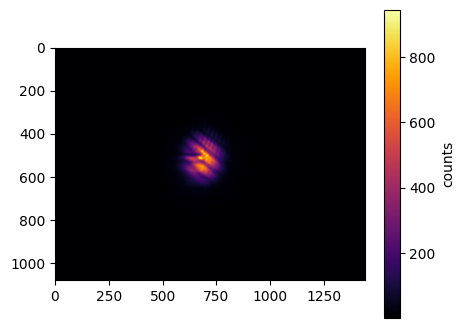

In [5]:
import numpy as np, time
import matplotlib.pyplot as plt

H, W = slm.shape

# pi step at fixed position
p = np.zeros((H, W))
p[H//2 - 115:, :] = np.pi          # horizontal edge at row H//2 - 115
slm.set_phase(p, phase_correct=True, settle=True)

cam.set_exposure(0.000)
img = cam.get_image()

plt.figure(figsize=(5, 4))
plt.imshow(img, cmap="inferno")
plt.colorbar(label="counts")
plt.show()

# Beam Centering

In [3]:
import numpy as np, time
import time
from slmsuite.holography.toolbox import phase

def show_pi_step(slm, d, axis="y", blaze_vector=None, settle=True):
    """Half-plane pi step, offset d px from the SLM center along `axis`,
    on top of a full-screen blaze (blaze_vector in slmsuite kxy units)."""
    H, W = slm.shape
    yy, xx = np.mgrid[0:H, 0:W]
    if axis == "y":
        mask = yy > (H // 2 + d)
    else:
        mask = xx > (W // 2 + d)
    p = np.zeros((H, W))
    p[mask] = np.pi
    if blaze_vector is not None:
        p += phase.blaze(grid=slm, vector=blaze_vector)
    slm.set_phase(p, phase_correct=True, settle=settle)
    return p

def sweep_pi_step(slm, k, axis="y", start=-50, stop=50, step=10, dwell_s=2.0):
    for d in np.arange(start, stop + 1, step):
        show_pi_step(slm, int(d), axis=axis, blaze_vector=k)
        print(f"{axis} = {d:+d}")
        time.sleep(dwell_s)


sweep_pi_step(slm, k=(0.0, -0.015), axis="y", start=114, stop=122, step=2, dwell_s=5.0)

y = +114
y = +116
y = +118
y = +120
y = +122


In [2]:
H, W = slm.shape

def show_annulus(slm, center, r_cut_px=50, blaze_vector=(0.0, -0.015), settle=True):
    """Blaze only OUTSIDE r_cut -> thin-ring 1st order; core stays in dumped 0th."""
    H, W = slm.shape
    cy, cx = center
    yy, xx = np.mgrid[0:H, 0:W]
    outside = (yy - cy)**2 + (xx - cx)**2 > r_cut_px**2
    p = np.where(outside, phase.blaze(grid=slm, vector=blaze_vector), 0.0)
    slm.set_phase(p, phase_correct=True, settle=settle)
    return p

p = show_annulus(slm, center=(H//2 + 126, W//2 + 240), r_cut_px=20)

# Polarization Code

In [33]:
import numpy as np
from slmsuite.holography.toolbox import phase

def write_blaze_plus_phase(slm, vector=(0.025, 0.0), gamma=0.0, settle=True):
    """
    Display (blazed grating toward `vector`) + (uniform retardance `gamma`).
    Vendor phase correction is applied automatically by set_phase(phase_correct=True),
    so it is NOT added here (adding it manually would double-count it).

    vector : (kx/k, ky/k) normalized blaze direction (sin theta). Default ~1.4 deg in x.
    gamma  : uniform phase in radians added on top of the blaze.
    """
    blz = phase.blaze(grid=slm, vector=vector)          # linear ramp, radians
    total = blz + float(gamma)                          # piston rides on the ramp
    slm.set_phase(total, phase_correct=True, settle=settle)   # vendor corr auto-added
    return total

# example: blaze to strip 0th order, with a pi/2 uniform retardance on top
write_blaze_plus_phase(slm, vector=(0.0, 0.01), gamma=0.0)

array([[-377.56688024, -377.56688024, -377.56688024, ..., -377.56688024,
        -377.56688024, -377.56688024],
       [-376.82872407, -376.82872407, -376.82872407, ..., -376.82872407,
        -376.82872407, -376.82872407],
       [-376.09056791, -376.09056791, -376.09056791, ..., -376.09056791,
        -376.09056791, -376.09056791],
       ...,
       [ 376.09056791,  376.09056791,  376.09056791, ...,  376.09056791,
         376.09056791,  376.09056791],
       [ 376.82872407,  376.82872407,  376.82872407, ...,  376.82872407,
         376.82872407,  376.82872407],
       [ 377.56688024,  377.56688024,  377.56688024, ...,  377.56688024,
         377.56688024,  377.56688024]], shape=(1024, 1280))

In [34]:
import numpy as np
import time

def sweep_gamma_live(slm, gammas=None, dwell_s=3.0, loop=True,
                     settle=True, verbose=True):
    """
    Cycle a uniform retardance Gamma across the panel, pausing at each value
    so you can watch the PAX ellipticity/Poincare respond. No blaze: both
    polarization components co-propagate. Vendor correction auto-applied.

    slm      : your ScreenMirrored object
    gammas   : array of Gamma values in radians (default 0..2pi in 12 steps)
    dwell_s  : seconds to hold each Gamma so the polarimeter can settle+read
    loop     : if True, repeat forever until interrupted (Ctrl-C / stop cell)
    """
    if gammas is None:
        gammas = np.linspace(0, np.pi, 12, endpoint=False)

    try:
        while True:
            for g in gammas:
                phase = np.full(slm.shape, float(g), dtype=float)
                slm.set_phase(phase, phase_correct=True, settle=settle)
                if verbose:
                    print(f"Gamma = {g:6.3f} rad = {np.degrees(g):6.1f} deg")
                time.sleep(dwell_s)
            if not loop:
                break
    except KeyboardInterrupt:
        print("Sweep stopped.")

# run it
sweep_gamma_live(slm, dwell_s=4.0, loop=True)

Gamma =  0.000 rad =    0.0 deg
Gamma =  0.262 rad =   15.0 deg
Sweep stopped.


In [ ]:
import numpy as np

A_FIT   = 0.986              # amplitude
F_FIT   = 1.260             # frequency
GAMMA0  = np.radians(15.7)   # phase offset (radians)

# CHI_MAX = 0.5*np.degrees(np.arcsin(min(A_FIT, 1.0)))  

def _gamma_from_s3(s3_target):
    ratio = s3_target / A_FIT
    if np.abs(ratio) > 1:
        raise ValueError(f"S3={s3_target} exceeds reachable +/-{A_FIT:.3f}")
    # f*Gamma - Gamma0 = arccos(ratio)  ->  Gamma = (arccos(ratio) + Gamma0)/f
    g = (np.arccos(ratio) + GAMMA0) / F_FIT
    return float(np.clip(g, 0.0, np.pi))

def set_ellipticity_from_S3(slm, s3_target, settle=True):
    g = _gamma_from_s3(s3_target)
    slm.set_phase(np.full(slm.shape, g), phase_correct=True, settle=settle)
    return g

def set_ellipticity(slm, chi_deg, settle=True):
    s3_target = np.sin(np.radians(2*chi_deg))
    if abs(s3_target) > A_FIT:
        raise ValueError(f"chi={chi_deg} deg unreachable (max +/-{CHI_MAX:.1f} deg)")
    g = _gamma_from_s3(s3_target)
    slm.set_phase(np.full(slm.shape, g), phase_correct=True, settle=settle)
    return g

In [ ]:
set_ellipticity(slm,1.006)     # ellipticity in degrees
# set_ellipticity_from_S3(slm, 0.35)  

In [ ]:
# magic_angle = 15.6
set_ellipticity(slm, 31.6)     # ellipticity in degrees

# Superpixel Calibration

In [ ]:
slm.write(None, settle=True)
slm.load_vendor_phase_correction("CAL_LSH0804050_1064nm.bmp")
cam.set_exposure(.3)
vec = fs.ijcam_to_kxyslm((-200,600))
movie = fs.wavefront_calibrate_superpixel(
    calibration_points=(1101, 301),
    field_point=vec,
    # field_point_units="freq",
    superpixel_size= 64,
    # corrected_amplitude=True,
    # reference_superpixels=(5,7),
    # fresh_calibration = False
    # test_index = 76,                       # Testing mode
    phase_steps= 10,                     # Special mode to step through phase for the .gif
    # plot=3                              # Special mode to generate a phase .gif
)

# from slmsuite.holography.analysis.files import save_image
# save_image("wavefront.gif", movie)

In [ ]:
fs.save_calibration("wavefront_superpixel")

In [ ]:
fs.wavefront_calibration_superpixel_process(r2_threshold=.4, smooth=True, plot=True);

# Beam Centering Testing

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ----------------------------
# Process + pull amplitude
# ----------------------------
fs.wavefront_calibration_superpixel_process(r2_threshold=0.4, smooth=True, plot=False)

A = np.asarray(slm.source["amplitude"], dtype=float)   # amplitude map (should be ~0..1)
I = A**2                                               # fit intensity

# ----------------------------
# Pitch (µm) helper
# ----------------------------
def get_pitch_um(slm, fallback_um=12.5):
    if hasattr(slm, "pitch_um") and slm.pitch_um is not None:
        px, py = slm.pitch_um
        return float(px), float(py)
    return float(fallback_um), float(fallback_um)

pitch_x_um, pitch_y_um = get_pitch_um(slm, fallback_um=12.5)

# ----------------------------
# Centroid for initial guess (center printed in pixels)
# ----------------------------
yy, xx = np.indices(I.shape)
Itot = I.sum()
x_c = (I * xx).sum() / Itot
y_c = (I * yy).sum() / Itot

var_x = (I * (xx - x_c)**2).sum() / Itot
var_y = (I * (yy - y_c)**2).sum() / Itot
sig_x = np.sqrt(var_x)
sig_y = np.sqrt(var_y)

# ----------------------------
# 2D Gaussian model for intensity
# I = I0 * exp(-2[(x-x0)^2/wx^2 + (y-y0)^2/wy^2]) + B
# 1/e^2 diameter = 2*w
# ----------------------------
def gaussian2d_xy(coords, I0, x0, y0, wx, wy, B):
    x, y = coords
    return (I0 * np.exp(-2.0 * ((x - x0)**2 / (wx**2) + (y - y0)**2 / (wy**2))) + B).ravel()

# ROI to stabilize fit
Imax = I.max()
roi = I > (0.15 * Imax)
if roi.sum() < 200:
    roi = I > (0.05 * Imax)

x_roi = xx[roi].astype(float)
y_roi = yy[roi].astype(float)
I_roi = I[roi].astype(float)

I0_guess = float(I_roi.max() - np.median(I_roi))
B_guess  = float(np.median(I_roi))
wx_guess = float(max(20.0, 2.0 * sig_x))
wy_guess = float(max(20.0, 2.0 * sig_y))
p0 = (I0_guess, float(x_c), float(y_c), wx_guess, wy_guess, B_guess)

bounds = (
    (0.0, 0.0, 0.0, 1.0, 1.0, -np.inf),
    (np.inf, I.shape[1], I.shape[0], np.inf, np.inf, np.inf),
)

popt, _ = curve_fit(
    gaussian2d_xy,
    (x_roi, y_roi),
    I_roi.ravel(),
    p0=p0,
    bounds=bounds,
    maxfev=20000
)

I0_fit, x0_fit, y0_fit, wx_fit, wy_fit, B_fit = popt

# Convert 1/e^2 diameters to microns only
Dx_um = (2.0 * wx_fit) * pitch_x_um
Dy_um = (2.0 * wy_fit) * pitch_y_um

# ----------------------------
# Display: measured intensity + fitted model (Gaussian fit only)
# ----------------------------
I_fit_img = gaussian2d_xy((xx.astype(float), yy.astype(float)),
                          I0_fit, x0_fit, y0_fit, wx_fit, wy_fit, B_fit).reshape(I.shape)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
im1 = plt.imshow(I, origin="upper", cmap="viridis")
plt.title("Measured (I = amplitude$^2$)")
plt.xlabel("SLM x [pix]")
plt.ylabel("SLM y [pix]")
plt.colorbar(im1, fraction=0.046, pad=0.04)

plt.subplot(1, 2, 2)
im2 = plt.imshow(I_fit_img, origin="upper", cmap="viridis")
plt.title("Gaussian Fit")
plt.xlabel("SLM x [pix]")
plt.ylabel("SLM y [pix]")
plt.colorbar(im2, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# ----------------------------
# Print: center in pixels, diameter in microns
# ----------------------------
print(f"Gaussian-fit center (x,y) [pix]: ({x0_fit:.2f}, {y0_fit:.2f})")
print(f"Gaussian-fit 1/e^2 diameter (Dx,Dy) [um]: ({Dx_um:.1f}, {Dy_um:.1f})")
print(f"Pitch used (x,y) [um]: ({pitch_x_um}, {pitch_y_um})")


In [ ]:
import numpy as np
from slmsuite.holography import toolbox
from slmsuite.holography.toolbox import phase

# Desired center (SLM pixel coords)
cx, cy = 620, 567
f = 1.15e7  # focal length in wavelengths

# Shift the grid so the lens is centered at (cx, cy)
x0 = slm.shape[1] / 2.0
y0 = slm.shape[0] / 2.0
dx_pix = cx - x0
dy_pix = cy - y0

shifted_grid = toolbox.transform_grid(
    slm,
    shift=(-dx_pix * slm.pitch[0], -dy_pix * slm.pitch[1])
)

lens_phase = phase.lens(grid=shifted_grid, f=f)

slm.write(None, settle=True)

# Camera
fs.cam.set_exposure(0.0001)
fs.cam.flush(1)
img = fs.cam.get_image()
fs.cam.plot(img)



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from slmsuite.holography import toolbox
from slmsuite.holography.toolbox import phase

# -------------------------
# Fixed params
# -------------------------
f1 = 0.47e6
f2 = 0.44e6
cy = 567
exposure = 0.001

cx_values = np.arange(500, 600 + 1e-9, 4)

# SLM center
x0 = slm.shape[1] / 2.0
y0 = slm.shape[0] / 2.0

fs.cam.set_exposure(exposure)

def peak_xy(img):
    I = img.astype(float)
    py, px = np.unravel_index(np.argmax(I), I.shape)
    return float(px), float(py)

dx_list = []
dy_list = []
dr_list = []

for cx in cx_values:
    # Common shifted grid for this cx
    shifted_grid = toolbox.transform_grid(
        slm,
        shift=(-(cx - x0) * slm.pitch[0], -(cy - y0) * slm.pitch[1])
    )

    # --- f1 ---
    slm.write(phase.lens(grid=shifted_grid, f=f1), settle=True)
    fs.cam.flush(1)
    img1 = fs.cam.get_image()
    x1, y1 = peak_xy(img1)

    # --- f2 ---
    slm.write(phase.lens(grid=shifted_grid, f=f2), settle=True)
    fs.cam.flush(1)
    img2 = fs.cam.get_image()
    x2, y2 = peak_xy(img2)

    dx = x2 - x1
    dy = y2 - y1
    dr = np.sqrt(dx*dx + dy*dy)

    dx_list.append(dx)
    dy_list.append(dy)
    dr_list.append(dr)

dx_list = np.array(dx_list)
dy_list = np.array(dy_list)
dr_list = np.array(dr_list)

# -------------------------
# Plot displacement vs cx
# -------------------------
plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

plt.figure(figsize=(7.5, 4.8))
plt.plot(cx_values, dx_list, "o-", color="#06aeef", linewidth=2, label=r"$\Delta x$ (cam px)")
plt.plot(cx_values, dy_list, "o-", color="k", linewidth=2, label=r"$\Delta y$ (cam px)")
plt.plot(cx_values, dr_list, "o-", color="gray", linewidth=2, label=r"$\sqrt{\Delta x^2+\Delta y^2}$")

plt.xlabel("cx (SLM pixels)")
plt.ylabel("Peak displacement: f2 - f1 (camera pixels)")
plt.grid(False)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# Print a quick summary
i_best = int(np.argmin(dr_list))
print(f"Smallest displacement at cx = {cx_values[i_best]} (SLM pix)")
print(f"At that cx: dx={dx_list[i_best]:.3f}, dy={dy_list[i_best]:.3f}, dr={dr_list[i_best]:.3f} (camera px)")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from slmsuite.holography import toolbox
from slmsuite.holography.toolbox import phase

# -------------------------
# Fixed params (edit as needed)
# -------------------------
f = 0.47e6
cy = 567
exposure = 0.0001

# Sweep cx
cx_values = np.arange(480, 600 + 1e-9, 1)

# Precompute SLM center
x0 = slm.shape[1] / 2.0
y0 = slm.shape[0] / 2.0

# Camera settings
fs.cam.set_exposure(exposure)

# -------------------------
# Sweep: measure peak intensity (max pixel value)
# -------------------------
peak_vals = []

for cx in cx_values:
    shifted_grid = toolbox.transform_grid(
        slm,
        shift=(-(cx - x0) * slm.pitch[0], -(cy - y0) * slm.pitch[1])
    )

    lens_phase = phase.lens(grid=shifted_grid, f=f)
    slm.write(lens_phase, settle=True)

    fs.cam.flush(2)
    img = fs.cam.get_image()
    peak_vals.append(float(np.max(img)))

peak_vals = np.array(peak_vals)

# -------------------------
# Plot peak vs cx
# -------------------------
plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

plt.figure(figsize=(7.5, 4.8))
plt.plot(cx_values, peak_vals, "o-", color="#06aeef", linewidth=2)

plt.xlabel("cx (SLM pixels)")
plt.ylabel("Peak intensity (max pixel, arb.)")
plt.grid(False)
plt.tight_layout()
plt.show()

best_i = int(np.argmax(peak_vals))
print(f"Max peak at cx = {cx_values[best_i]} (SLM pix),  I_max = {peak_vals[best_i]:.6g}")



# Diffraction-Limited Testing

In [ ]:
from slmsuite.holography import analysis

vec  = fs.ijcam_to_kxyslm((300,600))
blaze = toolbox.phase.blaze(grid=slm, vector=vec)
slm.write(blaze)
fs.cam.set_exposure(0.0001)
img = fs.cam.get_image()
fs.cam.plot(img);
subimage = analysis.take(img, vectors=[300,600], size=75)
analysis.take_plot(subimage) 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from slmsuite.holography import analysis

# --- parameters ---
vec_cam = (300, 635)   # camera coordinates where you take the subimage
size = 75              # matches your analysis.take(..., size=75)

# --- get subimage (H,W) ---
sub = analysis.take(img, vectors=[vec_cam], size=size)
sub = np.asarray(sub)
if sub.ndim == 3:
    sub = sub[0]  # (H,W)

I = sub.astype(float)
H, W = I.shape
Y, X = np.mgrid[0:H, 0:W]

# --- 2D Gaussian + constant background ---
def gauss2d(coords, A, x0, y0, sx, sy, B):
    x, y = coords
    return (A * np.exp(-(((x - x0)**2)/(2*sx**2) + ((y - y0)**2)/(2*sy**2))) + B).ravel()

# --- initial guesses ---
B0 = float(np.percentile(I, 10))
A0 = float(I.max() - B0)
x0_0 = float(W/2)
y0_0 = float(H/2)
sx0 = 5.0
sy0 = 5.0
p0 = (A0, x0_0, y0_0, sx0, sy0, B0)

# bounds: positive widths
bounds = ([-np.inf, 0, 0, 1e-3, 1e-3, -np.inf],
          [ np.inf, W, H,  np.inf,  np.inf,  np.inf])

popt, pcov = curve_fit(
    gauss2d,
    (X, Y),
    I.ravel(),
    p0=p0,
    bounds=bounds,
    maxfev=20000
)

A, x0, y0, sx, sy, B = popt

# --- fitted image + R^2 ---
fit = (A * np.exp(-(((X - x0)**2)/(2*sx**2) + ((Y - y0)**2)/(2*sy**2))) + B)
ss_res = np.sum((I - fit)**2)
ss_tot = np.sum((I - np.mean(I))**2)
R2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan

# --- 1/e^2 diameter: diameter = 4*sigma (for exp(-r^2/(2 sigma^2))) ---
Dx_pix = 4.0 * sx
Dy_pix = 4.0 * sy

# camera pitch (µm/pixel)
pitch_um = fs.cam.pitch_um
if np.isscalar(pitch_um):
    px_um = py_um = float(pitch_um)
else:
    px_um, py_um = float(pitch_um[0]), float(pitch_um[1])

Dx_um = Dx_pix * px_um
Dy_um = Dy_pix * py_um

# --- convert fitted center in subimage coords -> absolute camera coords ---
# analysis.take(..., vectors=[(x,y)], size=S) returns an SxS window centered on vec_cam
# So subimage pixel (W/2, H/2) corresponds to vec_cam approximately.
x_abs = vec_cam[0] + (x0 - (W - 1)/2)
y_abs = vec_cam[1] + (y0 - (H - 1)/2)

print(f"Fit center (subimage px): x0={x0:.2f}, y0={y0:.2f}")
print(f"Fit center (camera px):  x={x_abs:.2f}, y={y_abs:.2f}   (target ~ {vec_cam})")
print(f"Sigma (px): sx={sx:.2f}, sy={sy:.2f}")
print(f"1/e^2 diameter (px): Dx={Dx_pix:.2f}, Dy={Dy_pix:.2f}")
print(f"1/e^2 diameter (um): Dx={Dx_um:.1f} µm, Dy={Dy_um:.1f} µm")
print(f"R^2 = {R2:.5f}")

# --- plots ---
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(I, origin="upper")
plt.title("Subimage")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(fit, origin="upper")
plt.title("Gaussian fit")
plt.axis("off")

plt.tight_layout()
plt.show()

# Zernike Calibration

## Imaging and Testing

In [ ]:
from slmsuite.holography.toolbox import phase
from slmsuite.holography import analysis
import numpy as np
import time
import matplotlib.pyplot as plt

# -----------------------------
# User knobs
# -----------------------------
weight  = -0.6
z_index = 4

roi_center = (300, 620)   # (row=i, col=j) on camera
roi_size   = 100
exposure   = 1e-4
sleep_s    = 0.2

# Shift the ZERNIKE PUPIL CENTER on the SLM (pixels, no wrap)
SHIFT_X = 0   # +x shifts right
SHIFT_Y = 0   # +y shifts down

# Desired Zernike pupil radius on the SLM (pixels)
r = 500

# -----------------------------
# Helpers
# -----------------------------
def _to_2d(subimage):
    I = np.asarray(subimage, dtype=float)
    I = np.squeeze(I)
    if I.ndim == 3:
        if I.shape[-1] in (3, 4):
            I = I.mean(axis=-1)
        else:
            I = I[0]
    if I.ndim != 2:
        raise ValueError(f"Expected 2D image, got shape {I.shape}")
    return I

def gaussian_fit_2d(subimage, background="percentile", bg_percentile=10, eps=1e-12):
    """
    Axis-aligned 2D Gaussian:
      I(x,y) = B + A * exp(-2*((x-x0)^2/wx^2 + (y-y0)^2/wy^2))

    Returns: (area, (x0,y0), fit_img, params)
      area = Dx*Dy, Dx=2wx, Dy=2wy (1/e^2 diameters, in ROI pixels)
    """
    from scipy.optimize import curve_fit

    Iraw = _to_2d(subimage)

    # background subtract (constant)
    if background is None:
        bg = 0.0
    elif background == "percentile":
        bg = float(np.percentile(Iraw, bg_percentile))
    else:
        bg = float(background)

    I = Iraw - bg
    I[I < 0] = 0.0

    total = I.sum()
    if total < eps:
        return np.nan, (np.nan, np.nan), np.zeros_like(I), {}

    H, W = I.shape
    yy, xx = np.indices((H, W))

    # moments init
    x0 = float((I * xx).sum() / total)
    y0 = float((I * yy).sum() / total)

    dx = xx - x0
    dy = yy - y0
    var_x = float((I * dx * dx).sum() / total)
    var_y = float((I * dy * dy).sum() / total)

    wx0 = max(2.0 * np.sqrt(max(var_x, 1e-12)), 1e-6)  # var = w^2/4
    wy0 = max(2.0 * np.sqrt(max(var_y, 1e-12)), 1e-6)

    A0 = max(float(I.max()), eps)
    B0 = 0.0

    def model(coord, A, B, x0, y0, wx, wy):
        x, y = coord
        return B + A * np.exp(-2.0 * (((x - x0) ** 2) / (wx ** 2) + ((y - y0) ** 2) / (wy ** 2)))

    xdata = np.vstack((xx.ravel(), yy.ravel()))
    ydata = I.ravel()

    p0 = (A0, B0, x0, y0, wx0, wy0)
    bounds = (
        (0.0, -np.inf, 0.0, 0.0, 1e-6, 1e-6),
        (np.inf,  np.inf, W - 1.0, H - 1.0, np.inf, np.inf),
    )

    try:
        popt, _ = curve_fit(model, xdata, ydata, p0=p0, bounds=bounds, maxfev=40000)
        A, B, x0f, y0f, wx, wy = [float(v) for v in popt]

        Dx = 2.0 * wx
        Dy = 2.0 * wy
        area = Dx * Dy

        fit_flat = model(xdata, *popt)
        fit_img = fit_flat.reshape(H, W)

        params = dict(A=A, B=B, x0=x0f, y0=y0f, wx=wx, wy=wy, Dx=Dx, Dy=Dy, bg=bg)
        return area, (x0f, y0f), fit_img, params
    except Exception:
        return np.nan, (np.nan, np.nan), np.zeros_like(I), {}

def make_zernike_scaled_radius(grid_like, index, weight, r_px, shift_x=0, shift_y=0):
    """
    Build Zernike on an explicit pixel-based normalized pupil:
      u = (x - cx)/r_px, v = (y - cy)/r_px  -> unit circle is radius r_px pixels.
    shift_x/shift_y move the pupil center in SLM pixels (no wrap).
    """
    H, W = grid_like.shape
    cy = (H - 1) / 2.0 + float(shift_y)
    cx = (W - 1) / 2.0 + float(shift_x)

    yy, xx = np.indices((H, W))
    xg = (xx - cx) / float(r_px)
    yg = (yy - cy) / float(r_px)

    # With (xg, yg) already normalized, use aperture=(1,1) so the pupil is xg^2+yg^2<=1
    z = phase.zernike(grid=(xg, yg), index=int(index), weight=float(weight), aperture=(1.0, 1.0))
    return z

# -----------------------------
# Build blaze and scaled Zernike
# -----------------------------
zernike_vec = fs.ijcam_to_kxyslm(roi_center)
blaze = phase.blaze(grid=slm, vector=zernike_vec)

z_scaled = make_zernike_scaled_radius(
    slm, index=z_index, weight=weight,
    r_px=r, shift_x=SHIFT_X, shift_y=SHIFT_Y
)

phi = np.pi * z_scaled + blaze

# Write phase (no vendor correction is explicitly applied here)
slm.write(phi, settle=True)
time.sleep(sleep_s)

# -----------------------------
# Acquire image + ROI
# -----------------------------
fs.cam.set_exposure(exposure)
fs.cam.flush(1)
img = fs.cam.get_image()
fs.cam.plot(img)

subimage = analysis.take(img, vectors=[roi_center], size=roi_size)
analysis.take_plot(subimage)

# -----------------------------
# Fit + print metrics
# -----------------------------
area, (x0, y0), fit_img, params = gaussian_fit_2d(subimage, background="percentile", bg_percentile=10)

print("title")
print(f"SLM Zernike radius r = {r} px | SHIFT_X={SHIFT_X}, SHIFT_Y={SHIFT_Y}")
print(f"Area (Dx·Dy)    = {area:.0f} px^2")
print(f"Center (x0, y0) = ({x0:.2f}, {y0:.2f}) [ROI pixels]")

# Convert ROI center -> camera pixel coords
i0, j0 = roi_center
half = roi_size // 2
top_row  = i0 - half
left_col = j0 - half
cam_x = left_col + x0   # camera col
cam_y = top_row  + y0   # camera row
print(f"Center in CAMERA pixels (col=x, row=y) = ({cam_x:.2f}, {cam_y:.2f})")

# Visualize fit
plt.figure(figsize=(5, 4))
im = plt.imshow(fit_img, origin="lower")
plt.title("2D Gaussian fit")
plt.axis("off")
plt.colorbar(im)
plt.tight_layout()
plt.show()

In [ ]:
from slmsuite.holography.toolbox import phase
from slmsuite.holography import analysis
import numpy as np
import time
import matplotlib.pyplot as plt

# --- set your desired weight here ---
# weight = 1.83

roi_center = (300, 600)
roi_size   = 100

# Blaze to steer away from 0th order
zernike_vec = fs.ijcam_to_kxyslm(roi_center)
blaze = phase.blaze(grid=slm, vector=zernike_vec)

# Zernike computed with aperture="cropped" so it fills the whole SLM grid
zernike_phase = np.pi * phase.zernike(
    grid=slm,
    index=4,
    weight=weight,
    aperture="cropped",
)

slm.write(zernike_phase, settle=True)
time.sleep(0.2)

# Camera capture + ROI plot
fs.cam.set_exposure(1e-4)
fs.cam.flush(1)
img = fs.cam.get_image()
fs.cam.plot(img)

subimage = analysis.take(img, vectors=[roi_center], size=roi_size)
analysis.take_plot(subimage)

## Zernike Misc. 

In [ ]:
from slmsuite.holography.toolbox import phase
from slmsuite.holography import analysis
import numpy as np
import time
import matplotlib.pyplot as plt

# ============================================================
# User knobs
# ============================================================
Z_INDICES = [4]          # testing
N_ITERS_PER_Z = 4
offsets = np.linspace(-0.5, 0.5, 10)

N_AVG = 5                      # frames averaged per batch
BATCH = 3                      # batches per weight (gives error bars)

roi_center = (300, 600)
roi_size   = 200
exposure   = 1e-4
sleep_s    = 1.0
aperture   = "cropped"

# -----------------------------
# NEW: choose loss function here
# -----------------------------
# Options:
#   "gaussian_area"          -> minimize (Dx*Dy)
#   "peak_intensity"         -> maximize (we internally minimize negative peak)
#   "gaussian_center_intensity" -> maximize mean intensity in a small window around fitted center
LOSS_NAME = "gaussian_area"
LOSS_WINDOW = 3   # half-window in pixels for gaussian_center_intensity (total size = (2*LOSS_WINDOW+1)^2)

# -----------------------------
# NEW: choose initial pixel shift here (wrap-around np.roll)
# -----------------------------
SHIFT_X = 0   # +x shifts right
SHIFT_Y = 0   # +y shifts down

# -----------------------------
# Initial SLM
# -----------------------------
slm.write(None, settle=True)

# ============================================================
# Helpers / Loss Functions
# ============================================================
def _to_2d(subimage):
    I = np.asarray(subimage, dtype=float)
    I = np.squeeze(I)
    if I.ndim == 3:
        if I.shape[-1] in (3, 4):
            I = I.mean(axis=-1)
        else:
            I = I[0]
    if I.ndim != 2:
        raise ValueError(f"Expected 2D image, got shape {I.shape}")
    return I

def _bg_subtract(Iraw, background="percentile", bg_percentile=10):
    if background is None:
        bg = 0.0
    elif background == "percentile":
        bg = float(np.percentile(Iraw, bg_percentile))
    else:
        bg = float(background)
    I = Iraw - bg
    I[I < 0] = 0.0
    return I

def shift_phase(phi, shift_x=0, shift_y=0):
    """Integer-pixel wrap-around shift (np.roll)."""
    out = np.asarray(phi)
    out = np.roll(out, int(shift_y), axis=0)
    out = np.roll(out, int(shift_x), axis=1)
    return out

def averaged_subimage(fs, roi_center, roi_size, n_avg=5):
    """Average ROI across n_avg frames and return 2D float."""
    acc = None
    count = 0
    for _ in range(n_avg):
        fs.cam.flush(1)
        img = fs.cam.get_image()
        sub = analysis.take(img, vectors=[roi_center], size=roi_size)
        I = _to_2d(sub)
        if acc is None:
            acc = np.zeros_like(I, dtype=float)
        acc += I
        count += 1
    return acc / max(count, 1)

# ---- 2D Gaussian fit: returns area and fitted center (x0,y0) for center-window loss
def gaussian_fit_2d_area_and_center(Iraw_or_subimage, background="percentile", bg_percentile=10, eps=1e-12):
    """
    Axis-aligned 2D Gaussian:
      I(x,y) = B + A exp(-2((x-x0)^2/wx^2 + (y-y0)^2/wy^2))
    Returns:
      area = (2wx)*(2wy) = Dx*Dy
      (x0,y0) in pixel coords of ROI (float)
    """
    from scipy.optimize import curve_fit

    Iraw = Iraw_or_subimage if (isinstance(Iraw_or_subimage, np.ndarray) and Iraw_or_subimage.ndim == 2) else _to_2d(Iraw_or_subimage)
    I = _bg_subtract(Iraw, background=background, bg_percentile=bg_percentile)

    total = I.sum()
    if total < eps:
        return np.nan, (np.nan, np.nan)

    H, W = I.shape
    yy, xx = np.indices((H, W))

    x0 = float((I * xx).sum() / total)
    y0 = float((I * yy).sum() / total)

    dx = xx - x0
    dy = yy - y0
    var_x = float((I * dx * dx).sum() / total)
    var_y = float((I * dy * dy).sum() / total)

    wx0 = max(2.0 * np.sqrt(max(var_x, 1e-12)), 1e-6)
    wy0 = max(2.0 * np.sqrt(max(var_y, 1e-12)), 1e-6)

    A0 = max(float(I.max()), eps)
    B0 = 0.0

    def model(coord, A, B, x0, y0, wx, wy):
        x, y = coord
        return B + A * np.exp(-2.0 * (((x - x0) ** 2) / (wx ** 2) + ((y - y0) ** 2) / (wy ** 2)))

    xdata = np.vstack((xx.ravel(), yy.ravel()))
    ydata = I.ravel()

    p0 = (A0, B0, x0, y0, wx0, wy0)
    bounds = (
        (0.0, -np.inf, 0.0, 0.0, 1e-6, 1e-6),
        (np.inf,  np.inf, W - 1.0, H - 1.0, np.inf, np.inf),
    )

    try:
        popt, _ = curve_fit(model, xdata, ydata, p0=p0, bounds=bounds, maxfev=40000)
        x0f, y0f = float(popt[2]), float(popt[3])
        wx, wy = float(popt[4]), float(popt[5])
        Dx = 2.0 * wx
        Dy = 2.0 * wy
        area = float(Dx * Dy)
        return area, (x0f, y0f)
    except Exception:
        return np.nan, (np.nan, np.nan)

# ---- Loss implementations (all return a scalar we MINIMIZE)
def loss_gaussian_area(Iavg):
    area, _ = gaussian_fit_2d_area_and_center(Iavg)
    return area  # minimize

def loss_peak_intensity(Iavg):
    I = _bg_subtract(Iavg, background="percentile", bg_percentile=10)
    peak = float(np.max(I))
    return -peak  # maximize peak => minimize negative peak

def loss_gaussian_center_intensity(Iavg, half_window=3):
    I = _bg_subtract(Iavg, background="percentile", bg_percentile=10)
    _, (x0, y0) = gaussian_fit_2d_area_and_center(Iavg)
    if not (np.isfinite(x0) and np.isfinite(y0)):
        return np.nan

    H, W = I.shape
    cx = int(round(x0))
    cy = int(round(y0))

    x1 = max(cx - half_window, 0)
    x2 = min(cx + half_window + 1, W)
    y1 = max(cy - half_window, 0)
    y2 = min(cy + half_window + 1, H)

    val = float(np.mean(I[y1:y2, x1:x2]))
    return -val  # maximize intensity => minimize negative intensity

def compute_loss(Iavg):
    if LOSS_NAME == "gaussian_area":
        return loss_gaussian_area(Iavg)
    elif LOSS_NAME == "peak_intensity":
        return loss_peak_intensity(Iavg)
    elif LOSS_NAME == "gaussian_center_intensity":
        return loss_gaussian_center_intensity(Iavg, half_window=LOSS_WINDOW)
    else:
        raise ValueError(f"Unknown LOSS_NAME={LOSS_NAME}")

def measure_loss_batched(fs, roi_center, roi_size, n_avg=5, n_batches=3):
    """Batch-average images, then compute loss once per batch."""
    vals = []
    for _ in range(n_batches):
        Iavg = averaged_subimage(fs, roi_center, roi_size, n_avg=n_avg)
        vals.append(compute_loss(Iavg))
    vals = np.asarray(vals, dtype=float)
    mean = float(np.nanmean(vals))
    std  = float(np.nanstd(vals))
    se   = float(std / np.sqrt(np.sum(np.isfinite(vals)))) if np.any(np.isfinite(vals)) else np.nan
    return mean, std, se

def weighted_quadratic_min(weights, y_mean, y_se, clip_to_range=True):
    """Weighted quadratic fit (minimization)."""
    w = np.asarray(weights, dtype=float)
    y = np.asarray(y_mean, dtype=float)
    se = np.asarray(y_se, dtype=float)

    m = np.isfinite(w) & np.isfinite(y) & np.isfinite(se) & (se > 0)
    if np.count_nonzero(m) < 3:
        if np.any(np.isfinite(y)):
            return float(w[np.nanargmin(y)]), None
        return np.nan, None

    w = w[m]; y = y[m]; se = se[m]
    wt = 1.0 / se
    coeffs = np.polyfit(w, y, deg=2, w=wt)  # [a,b,c]
    a, b, c = coeffs

    if not np.isfinite(a) or abs(a) < 1e-18:
        w_star = float(w[np.argmin(y)])
    else:
        w_star = float(-b / (2.0 * a))
        if a < 0:  # concave => minimum at boundary
            w_star = float(w[np.argmin(y)])

    if clip_to_range:
        w_star = float(np.clip(w_star, np.min(w), np.max(w)))

    return w_star, coeffs

# ============================================================
# Setup blaze + camera
# ============================================================
zernike_vec = fs.ijcam_to_kxyslm(roi_center)
blaze = phase.blaze(grid=slm, vector=zernike_vec)
fs.cam.set_exposure(exposure)

# ============================================================
# Main multi-Zernike loop
# ============================================================
baseline_phase = np.zeros(slm.shape, dtype=float)
best_weights_by_index = np.full(len(Z_INDICES), np.nan)

global_iters = len(Z_INDICES) * N_ITERS_PER_Z
loss_map_global = np.full((len(offsets), global_iters), np.nan)
se_map_global   = np.full((len(offsets), global_iters), np.nan)

fit_records = []

global_it = 0
for zi, z_index in enumerate(Z_INDICES):
    centers = np.zeros(N_ITERS_PER_Z, dtype=float)

    for it in range(N_ITERS_PER_Z):
        w_center = centers[it]
        weights = w_center + offsets

        y_mean = np.full(len(weights), np.nan)
        y_se   = np.full(len(weights), np.nan)

        for j, w in enumerate(weights):
            z_phase = phase.zernike(grid=slm, index=z_index, weight=w, aperture=aperture)
            phi = baseline_phase + np.pi * z_phase + blaze

            # NEW: apply initial shift (wrap-around) to the full written phase
            if SHIFT_X != 0 or SHIFT_Y != 0:
                phi = shift_phase(phi, shift_x=SHIFT_X, shift_y=SHIFT_Y)

            slm.write(phi, settle=True)
            time.sleep(sleep_s)

            m, _, se = measure_loss_batched(fs, roi_center, roi_size, n_avg=N_AVG, n_batches=BATCH)
            y_mean[j] = m
            y_se[j]   = se

        loss_map_global[:, global_it] = y_mean
        se_map_global[:, global_it]   = y_se

        w_fit, coeffs = weighted_quadratic_min(weights, y_mean, y_se, clip_to_range=True)
        if not np.isfinite(w_fit):
            w_fit = float(weights[np.nanargmin(y_mean)]) if np.any(np.isfinite(y_mean)) else 0.0

        fit_records.append({
            "z_index": z_index,
            "iter": it + 1,
            "weights": weights.copy(),
            "mean": y_mean.copy(),
            "se": y_se.copy(),
            "coeffs": coeffs,
            "w_fit": float(w_fit),
            "global_it": global_it + 1,
        })

        if it + 1 < N_ITERS_PER_Z:
            centers[it + 1] = w_fit

        global_it += 1

    final_best_w = float(centers[-1])
    best_weights_by_index[zi] = final_best_w

    z_best = phase.zernike(grid=slm, index=z_index, weight=final_best_w, aperture=aperture)
    baseline_phase = baseline_phase + np.pi * z_best

# ============================================================
# Plot outputs
# ============================================================
plt.figure(figsize=(10, 4))
ax1 = plt.subplot(1, 2, 1)

im = ax1.imshow(
    loss_map_global,
    origin="lower",
    aspect="auto",
    cmap="Blues",
    extent=[0.5, global_iters + 0.5, offsets[0], offsets[-1]],
)
ax1.set_xlabel("Global iteration")
ax1.set_ylabel("Weight offset")
ax1.set_title(f"Loss = {LOSS_NAME} (mean over batches)")

plt.colorbar(im, ax=ax1, label="Mean loss (minimized)")

for k in range(1, len(Z_INDICES)):
    xline = k * N_ITERS_PER_Z + 0.5
    ax1.axvline(xline, color="k", linewidth=1)

for rec in fit_records:
    w_center = float(np.mean(rec["weights"]))
    y_off = rec["w_fit"] - w_center
    ax1.scatter([rec["global_it"]], [y_off], c="k", s=25, zorder=5)

ax2 = plt.subplot(1, 2, 2)
ax2.axis("off")
plt.tight_layout()
plt.show()

# Quadratic fits per z_index
for z_index in Z_INDICES:
    recs = [r for r in fit_records if r["z_index"] == z_index]
    if len(recs) == 0:
        continue

    fig, axes = plt.subplots(1, N_ITERS_PER_Z, figsize=(4*N_ITERS_PER_Z, 3), sharey=True)
    fig.suptitle(f"Quadratic fits per iteration (z_index={z_index})", y=1.05)

    for k, r in enumerate(recs):
        ax = axes[k] if N_ITERS_PER_Z > 1 else axes
        ax.errorbar(r["weights"], r["mean"], yerr=r["se"], fmt="o", capsize=3)
        ax.set_xlabel("Weight")
        ax.set_title(f"Iter {r['iter']}")

        coeffs = r["coeffs"]
        if coeffs is not None and np.all(np.isfinite(coeffs)):
            a, b, c = coeffs
            w_fine = np.linspace(np.min(r["weights"]), np.max(r["weights"]), 200)
            ax.plot(w_fine, a*w_fine**2 + b*w_fine + c, "-")
            ax.axvline(r["w_fit"], linestyle="--")
        else:
            ax.axvline(r["w_fit"], linestyle="--")

        if k == 0:
            ax.set_ylabel("Mean loss")

    plt.tight_layout()
    plt.show()

# ============================================================
# Print final "aberration array"
# ============================================================
print("LOSS_NAME:", LOSS_NAME)
print("SHIFT_X, SHIFT_Y:", SHIFT_X, SHIFT_Y)
print("Zernike indices:", Z_INDICES)
print("Best weights per index (same order):", best_weights_by_index)

zernike_weights_full = np.zeros(10, dtype=float) * np.nan
for z, w in zip(Z_INDICES, best_weights_by_index):
    zernike_weights_full[z] = w

print("Total zernike aberration array (index -> weight):")
print(zernike_weights_full)


## The Big Algorithm

In [ ]:
#good
from slmsuite.holography.toolbox import phase
from slmsuite.holography import analysis
import numpy as np
import time
import matplotlib.pyplot as plt

# ============================================================
# User knobs
# ============================================================
Z_INDICES = [4]
N_ITERS_PER_Z = 2
offsets = np.linspace(-0.5, 0.5, 15)

N_AVG = 5          # frames averaged per batch
BATCH = 3          # batches per weight (gives error bars)

roi_center = (300, 620)
roi_size   = 200
exposure   = 1e-4
sleep_s    = 1.0

# -----------------------------
# aperture + grid mode knobs
# -----------------------------
# NOTE:
#   "cropped"  = circle circumscribing the rectangle (will NOT fill corners)
#   "elliptical" = ellipse scaled to touch all 4 edges (best "fills screen" option)
APERTURE_MODE = "circular"     # "circular" or "cropped" or "elliptical"
USE_LEFT_HALF_GRID = False       # True -> compute Zernike on left-half grid and zero-pad to full SLM

# -----------------------------
# Loss function selection
# -----------------------------
LOSS_NAME = "gaussian_area"
LOSS_WINDOW = 3  # half-window in pixels for gaussian_center_intensity

# -----------------------------
# Initial pixel shift (wrap-around np.roll) applied to FULL written phase
# -----------------------------
SHIFT_X = 0   # +x shifts right
SHIFT_Y = 0   # +y shifts down

# -----------------------------
# plotting knobs
# -----------------------------
PLOT_QUADRATIC_FITS = True
SHOW_BEST_IMAGES    = True

# -----------------------------
# Initial SLM
# -----------------------------
slm.write(None, settle=True)

# ============================================================
# Helpers
# ============================================================
def _to_2d(subimage):
    I = np.asarray(subimage, dtype=float)
    I = np.squeeze(I)
    if I.ndim == 3:
        if I.shape[-1] in (3, 4):
            I = I.mean(axis=-1)
        else:
            I = I[0]
    if I.ndim != 2:
        raise ValueError(f"Expected 2D image, got shape {I.shape}")
    return I

def _bg_subtract(Iraw, background="percentile", bg_percentile=10):
    if background is None:
        bg = 0.0
    elif background == "percentile":
        bg = float(np.percentile(Iraw, bg_percentile))
    else:
        bg = float(background)
    I = Iraw - bg
    I[I < 0] = 0.0
    return I

def shift_phase(phi, shift_x=0, shift_y=0):
    out = np.asarray(phi)
    out = np.roll(out, int(shift_y), axis=0)
    out = np.roll(out, int(shift_x), axis=1)
    return out

def averaged_subimage(fs, roi_center, roi_size, n_avg=5):
    acc = None
    for _ in range(n_avg):
        fs.cam.flush(1)
        img = fs.cam.get_image()
        sub = analysis.take(img, vectors=[roi_center], size=roi_size)
        I = _to_2d(sub)
        if acc is None:
            acc = np.zeros_like(I, dtype=float)
        acc += I
    return acc / float(n_avg)

def _make_xy_grids(H, W):
    x = np.linspace(-1.0, 1.0, W, endpoint=True)
    y = np.linspace(-1.0, 1.0, H, endpoint=True)
    xx, yy = np.meshgrid(x, y)
    return xx, yy

def make_zernike_on_grid(grid_like, idx, weight, aperture_mode="circular", use_left_half=False):
    H, W = grid_like.shape

    if not use_left_half:
        return phase.zernike(grid=grid_like, index=int(idx), weight=float(weight), aperture=aperture_mode)

    W2 = W // 2
    xxL, yyL = _make_xy_grids(H, W2)

    try:
        z_left = phase.zernike(
            grid=(xxL, yyL),
            index=int(idx),
            weight=float(weight),
            aperture=aperture_mode,
        )
        z_full = np.zeros((H, W), dtype=float)
        z_full[:, :W2] = z_left
        return z_full
    except Exception:
        z_full = phase.zernike(grid=grid_like, index=int(idx), weight=float(weight), aperture=aperture_mode)
        z_full[:, W2:] = 0.0
        return z_full

def gaussian_fit_2d_area_and_center(Iraw, background="percentile", bg_percentile=10, eps=1e-12):
    from scipy.optimize import curve_fit

    I = _bg_subtract(Iraw, background=background, bg_percentile=bg_percentile)

    total = I.sum()
    if total < eps:
        return np.nan, (np.nan, np.nan)

    H, W = I.shape
    yy, xx = np.indices((H, W))

    x0 = float((I * xx).sum() / total)
    y0 = float((I * yy).sum() / total)

    dx = xx - x0
    dy = yy - y0
    var_x = float((I * dx * dx).sum() / total)
    var_y = float((I * dy * dy).sum() / total)

    wx0 = max(2.0 * np.sqrt(max(var_x, 1e-12)), 1e-6)
    wy0 = max(2.0 * np.sqrt(max(var_y, 1e-12)), 1e-6)

    A0 = max(float(I.max()), eps)
    B0 = 0.0

    def model(coord, A, B, x0, y0, wx, wy):
        x, y = coord
        return B + A * np.exp(-2.0 * (((x - x0) ** 2) / (wx ** 2) + ((y - y0) ** 2) / (wy ** 2)))

    xdata = np.vstack((xx.ravel(), yy.ravel()))
    ydata = I.ravel()

    p0 = (A0, B0, x0, y0, wx0, wy0)
    bounds = (
        (0.0, -np.inf, 0.0, 0.0, 1e-6, 1e-6),
        (np.inf,  np.inf, W - 1.0, H - 1.0, np.inf, np.inf),
    )

    try:
        popt, _ = curve_fit(model, xdata, ydata, p0=p0, bounds=bounds, maxfev=40000)
        x0f, y0f = float(popt[2]), float(popt[3])
        wx, wy   = float(popt[4]), float(popt[5])
        Dx = 2.0 * wx
        Dy = 2.0 * wy
        return float(Dx * Dy), (x0f, y0f)
    except Exception:
        return np.nan, (np.nan, np.nan)

# ---- Loss functions (all return a scalar we MINIMIZE)
def loss_gaussian_area(Iavg):
    area, _ = gaussian_fit_2d_area_and_center(Iavg)
    return area

def loss_peak_intensity(Iavg):
    I = _bg_subtract(Iavg, background="percentile", bg_percentile=10)
    return -float(np.max(I))

def loss_gaussian_center_intensity(Iavg, half_window=3):
    I = _bg_subtract(Iavg, background="percentile", bg_percentile=10)
    _, (x0, y0) = gaussian_fit_2d_area_and_center(Iavg)
    if not (np.isfinite(x0) and np.isfinite(y0)):
        return np.nan

    H, W = I.shape
    cx = int(round(x0))
    cy = int(round(y0))

    x1 = max(cx - half_window, 0)
    x2 = min(cx + half_window + 1, W)
    y1 = max(cy - half_window, 0)
    y2 = min(cy + half_window + 1, H)

    return -float(np.mean(I[y1:y2, x1:x2]))

def compute_loss(Iavg):
    if LOSS_NAME == "gaussian_area":
        return loss_gaussian_area(Iavg)
    elif LOSS_NAME == "peak_intensity":
        return loss_peak_intensity(Iavg)
    elif LOSS_NAME == "gaussian_center_intensity":
        return loss_gaussian_center_intensity(Iavg, half_window=LOSS_WINDOW)
    else:
        raise ValueError(f"Unknown LOSS_NAME={LOSS_NAME}")

def measure_loss_batched(fs, roi_center, roi_size, n_avg=5, n_batches=3):
    vals = []
    for _ in range(n_batches):
        Iavg = averaged_subimage(fs, roi_center, roi_size, n_avg=n_avg)
        vals.append(compute_loss(Iavg))

    vals = np.asarray(vals, dtype=float)
    mean = float(np.nanmean(vals))
    std  = float(np.nanstd(vals))
    n_eff = int(np.sum(np.isfinite(vals)))
    se   = float(std / np.sqrt(n_eff)) if n_eff > 0 else np.nan
    return mean, std, se

def weighted_quadratic_min(weights, y_mean, y_se, clip_to_range=True):
    w  = np.asarray(weights, dtype=float)
    y  = np.asarray(y_mean, dtype=float)
    se = np.asarray(y_se, dtype=float)

    m = np.isfinite(w) & np.isfinite(y) & np.isfinite(se) & (se > 0)
    if np.count_nonzero(m) < 3:
        if np.any(np.isfinite(y)):
            return float(w[np.nanargmin(y)]), None
        return np.nan, None

    w  = w[m]; y = y[m]; se = se[m]
    wt = 1.0 / se
    coeffs = np.polyfit(w, y, deg=2, w=wt)  # [a,b,c]
    a, b, c = coeffs

    if not np.isfinite(a) or abs(a) < 1e-18:
        w_star = float(w[np.argmin(y)])
    else:
        w_star = float(-b / (2.0 * a))
        if a < 0:
            w_star = float(w[np.argmin(y)])

    if clip_to_range:
        w_star = float(np.clip(w_star, np.min(w), np.max(w)))
    return w_star, coeffs

# ============================================================
# Setup blaze + camera
# ============================================================
zernike_vec = fs.ijcam_to_kxyslm(roi_center)
blaze = phase.blaze(grid=slm, vector=zernike_vec)
fs.cam.set_exposure(exposure)

# ============================================================
# Main multi-Zernike loop
# ============================================================
baseline_phase = np.zeros(slm.shape, dtype=float)  # radians
best_weights_by_index = np.full(len(Z_INDICES), np.nan)

for zi, z_index in enumerate(Z_INDICES):
    centers = np.zeros(N_ITERS_PER_Z, dtype=float)
    last_w_fit = np.nan  # <-- NEW: track the *actual* final fitted weight

    for it in range(N_ITERS_PER_Z):
        w_center = centers[it]
        weights = w_center + offsets

        y_mean = np.full(len(weights), np.nan)
        y_se   = np.full(len(weights), np.nan)

        for j, w in enumerate(weights):
            z_phase = make_zernike_on_grid(
                slm, z_index, w,
                aperture_mode=APERTURE_MODE,
                use_left_half=USE_LEFT_HALF_GRID
            )

            phi = baseline_phase + np.pi * z_phase + blaze
            if SHIFT_X != 0 or SHIFT_Y != 0:
                phi = shift_phase(phi, shift_x=SHIFT_X, shift_y=SHIFT_Y)

            slm.write(phi, settle=True)
            time.sleep(sleep_s)

            m, _, se = measure_loss_batched(fs, roi_center, roi_size, n_avg=N_AVG, n_batches=BATCH)
            y_mean[j] = m
            y_se[j]   = se

        w_fit, coeffs = weighted_quadratic_min(weights, y_mean, y_se, clip_to_range=True)
        if not np.isfinite(w_fit):
            w_fit = float(weights[np.nanargmin(y_mean)]) if np.any(np.isfinite(y_mean)) else 0.0

        last_w_fit = float(w_fit)  # <-- NEW: this is the best for *this* iteration

        if it + 1 < N_ITERS_PER_Z:
            centers[it + 1] = w_fit

        if PLOT_QUADRATIC_FITS:
            plt.figure(figsize=(6, 4))
            plt.errorbar(weights, y_mean, yerr=y_se, fmt="o", capsize=3)
            plt.xlabel("Weight")
            plt.ylabel("Mean loss")
            plt.title(f"z_index={z_index} | iter={it+1} | loss={LOSS_NAME}")

            if coeffs is not None and np.all(np.isfinite(coeffs)):
                a, b, c = coeffs
                w_fine = np.linspace(np.min(weights), np.max(weights), 200)
                plt.plot(w_fine, a*w_fine**2 + b*w_fine + c, "-")
            plt.axvline(w_fit, linestyle="--")
            plt.tight_layout()
            plt.show()

        if SHOW_BEST_IMAGES:
            z_best = make_zernike_on_grid(
                slm, z_index, w_fit,
                aperture_mode=APERTURE_MODE,
                use_left_half=USE_LEFT_HALF_GRID
            )
            phi_best = baseline_phase + np.pi * z_best + blaze
            if SHIFT_X != 0 or SHIFT_Y != 0:
                phi_best = shift_phase(phi_best, shift_x=SHIFT_X, shift_y=SHIFT_Y)

            slm.write(phi_best, settle=True)
            time.sleep(sleep_s)

            Ibest = averaged_subimage(fs, roi_center, roi_size, n_avg=N_AVG)
            plt.figure(figsize=(5, 4))
            im = plt.imshow(Ibest, origin="lower")
            plt.title(f"z_index={z_index} | iter={it+1} | w_fit={w_fit:.4g}")
            plt.axis("off")
            plt.colorbar(im)
            plt.tight_layout()
            plt.show()

    # ---- FINAL BEST WEIGHT FOR THIS z_index ----
    final_best_w = last_w_fit if np.isfinite(last_w_fit) else float(centers[-1])
    best_weights_by_index[zi] = final_best_w

    z_best_full = make_zernike_on_grid(
        slm, z_index, final_best_w,
        aperture_mode=APERTURE_MODE,
        use_left_half=USE_LEFT_HALF_GRID
    )
    baseline_phase = baseline_phase + np.pi * z_best_full

# ============================================================
# Print results (now truly final)
# ============================================================
print("LOSS_NAME:", LOSS_NAME)
print("APERTURE_MODE:", APERTURE_MODE)
print("USE_LEFT_HALF_GRID:", USE_LEFT_HALF_GRID)
print("SHIFT_X, SHIFT_Y:", SHIFT_X, SHIFT_Y)
print("Z_INDICES:", Z_INDICES)
print("Final best weights per index (same order):", best_weights_by_index)

zernike_weights_full = np.zeros(10, dtype=float) * np.nan
for z, w in zip(Z_INDICES, best_weights_by_index):
    zernike_weights_full[int(z)] = float(w)

print("Total zernike aberration array (index -> weight):")
print(zernike_weights_full)


## Global Iteration (Parameter Independence Testing)

In [ ]:
from slmsuite.holography.toolbox import phase
from slmsuite.holography import analysis
import numpy as np
import time
import matplotlib.pyplot as plt

# ============================================================
# User knobs
# ============================================================
Z_INDICES = [4, 5, 6, 7, 8, 9]     # full set
N_ITERS_PER_Z = 3
offsets = np.linspace(-0.5, 0.5, 15)

N_AVG = 5                      # frames averaged per batch
BATCH = 3                      # batches per weight (gives error bars)

roi_center = (300, 600)
roi_size   = 200
exposure   = 1e-4
sleep_s    = 1.0
aperture   = "circular"

# -----------------------------
# NEW: repeat full 4..9 optimization this many times
# -----------------------------
N_PASSES = 2

# If True: each pass re-starts from the same INITIAL baseline (good to test repeatability/noise).
# If False: pass 2 starts from pass-1’s optimized baseline (good to test coupling / stability).
RESTART_BASELINE_EACH_PASS = False

# -----------------------------
# Choose loss function here
# -----------------------------
# Options:
#   "gaussian_area"               -> minimize (Dx*Dy)
#   "peak_intensity"              -> maximize (we minimize negative peak)
#   "gaussian_center_intensity"   -> maximize mean intensity in a small window around fitted center
LOSS_NAME = "gaussian_area"
LOSS_WINDOW = 3

# -----------------------------
# Optional initial pixel shift (wrap-around np.roll)
# -----------------------------
SHIFT_X = 0
SHIFT_Y = 0

# -----------------------------
# Initial baseline Zernikes applied BEFORE each pass (optional)
# -----------------------------
# Set to None to disable.
INITIAL_Z_INDICES = [4, 5, 6, 7, 8, 9]
INITIAL_Z_WEIGHTS = [0.82, 0.22, -0.10, 0.06, -0.07, 0.16]   # <-- your initial guess weights

# -----------------------------
# Initial SLM
# -----------------------------
slm.write(None, settle=True)

# ============================================================
# Helpers / Loss Functions
# ============================================================
def _to_2d(subimage):
    I = np.asarray(subimage, dtype=float)
    I = np.squeeze(I)
    if I.ndim == 3:
        if I.shape[-1] in (3, 4):
            I = I.mean(axis=-1)
        else:
            I = I[0]
    if I.ndim != 2:
        raise ValueError(f"Expected 2D image, got shape {I.shape}")
    return I

def _bg_subtract(Iraw, background="percentile", bg_percentile=10):
    if background is None:
        bg = 0.0
    elif background == "percentile":
        bg = float(np.percentile(Iraw, bg_percentile))
    else:
        bg = float(background)
    I = Iraw - bg
    I[I < 0] = 0.0
    return I

def shift_phase(phi, shift_x=0, shift_y=0):
    out = np.asarray(phi)
    out = np.roll(out, int(shift_y), axis=0)
    out = np.roll(out, int(shift_x), axis=1)
    return out

def averaged_subimage(fs, roi_center, roi_size, n_avg=5):
    acc = None
    for _ in range(n_avg):
        fs.cam.flush(1)
        img = fs.cam.get_image()
        sub = analysis.take(img, vectors=[roi_center], size=roi_size)
        I = _to_2d(sub)
        if acc is None:
            acc = np.zeros_like(I, dtype=float)
        acc += I
    return acc / float(max(n_avg, 1))

def gaussian_fit_2d_area_and_center(Iraw_or_subimage, background="percentile", bg_percentile=10, eps=1e-12):
    from scipy.optimize import curve_fit

    Iraw = Iraw_or_subimage if (isinstance(Iraw_or_subimage, np.ndarray) and Iraw_or_subimage.ndim == 2) else _to_2d(Iraw_or_subimage)
    I = _bg_subtract(Iraw, background=background, bg_percentile=bg_percentile)

    total = I.sum()
    if total < eps:
        return np.nan, (np.nan, np.nan)

    H, W = I.shape
    yy, xx = np.indices((H, W))

    x0 = float((I * xx).sum() / total)
    y0 = float((I * yy).sum() / total)

    dx = xx - x0
    dy = yy - y0
    var_x = float((I * dx * dx).sum() / total)
    var_y = float((I * dy * dy).sum() / total)

    wx0 = max(2.0 * np.sqrt(max(var_x, 1e-12)), 1e-6)
    wy0 = max(2.0 * np.sqrt(max(var_y, 1e-12)), 1e-6)

    A0 = max(float(I.max()), eps)
    B0 = 0.0

    def model(coord, A, B, x0, y0, wx, wy):
        x, y = coord
        return B + A * np.exp(-2.0 * (((x - x0) ** 2) / (wx ** 2) + ((y - y0) ** 2) / (wy ** 2)))

    xdata = np.vstack((xx.ravel(), yy.ravel()))
    ydata = I.ravel()

    p0 = (A0, B0, x0, y0, wx0, wy0)
    bounds = (
        (0.0, -np.inf, 0.0, 0.0, 1e-6, 1e-6),
        (np.inf,  np.inf, W - 1.0, H - 1.0, np.inf, np.inf),
    )

    try:
        popt, _ = curve_fit(model, xdata, ydata, p0=p0, bounds=bounds, maxfev=40000)
        x0f, y0f = float(popt[2]), float(popt[3])
        wx, wy = float(popt[4]), float(popt[5])
        Dx = 2.0 * wx
        Dy = 2.0 * wy
        return float(Dx * Dy), (x0f, y0f)
    except Exception:
        return np.nan, (np.nan, np.nan)

# ---- Loss implementations (all return a scalar we MINIMIZE)
def loss_gaussian_area(Iavg):
    area, _ = gaussian_fit_2d_area_and_center(Iavg)
    return area

def loss_peak_intensity(Iavg):
    I = _bg_subtract(Iavg, background="percentile", bg_percentile=10)
    return -float(np.max(I))

def loss_gaussian_center_intensity(Iavg, half_window=3):
    I = _bg_subtract(Iavg, background="percentile", bg_percentile=10)
    _, (x0, y0) = gaussian_fit_2d_area_and_center(Iavg)
    if not (np.isfinite(x0) and np.isfinite(y0)):
        return np.nan
    H, W = I.shape
    cx = int(round(x0))
    cy = int(round(y0))
    x1 = max(cx - half_window, 0)
    x2 = min(cx + half_window + 1, W)
    y1 = max(cy - half_window, 0)
    y2 = min(cy + half_window + 1, H)
    return -float(np.mean(I[y1:y2, x1:x2]))

def compute_loss(Iavg):
    if LOSS_NAME == "gaussian_area":
        return loss_gaussian_area(Iavg)
    if LOSS_NAME == "peak_intensity":
        return loss_peak_intensity(Iavg)
    if LOSS_NAME == "gaussian_center_intensity":
        return loss_gaussian_center_intensity(Iavg, half_window=LOSS_WINDOW)
    raise ValueError(f"Unknown LOSS_NAME={LOSS_NAME}")

def measure_loss_batched(fs, roi_center, roi_size, n_avg=5, n_batches=3):
    vals = []
    for _ in range(n_batches):
        Iavg = averaged_subimage(fs, roi_center, roi_size, n_avg=n_avg)
        vals.append(compute_loss(Iavg))
    vals = np.asarray(vals, dtype=float)
    mean = float(np.nanmean(vals))
    std  = float(np.nanstd(vals))
    se   = float(std / np.sqrt(np.sum(np.isfinite(vals)))) if np.any(np.isfinite(vals)) else np.nan
    return mean, std, se

def weighted_quadratic_min(weights, y_mean, y_se, clip_to_range=True):
    w = np.asarray(weights, dtype=float)
    y = np.asarray(y_mean, dtype=float)
    se = np.asarray(y_se, dtype=float)

    m = np.isfinite(w) & np.isfinite(y) & np.isfinite(se) & (se > 0)
    if np.count_nonzero(m) < 3:
        if np.any(np.isfinite(y)):
            return float(w[np.nanargmin(y)]), None
        return np.nan, None

    w = w[m]; y = y[m]; se = se[m]
    wt = 1.0 / se
    coeffs = np.polyfit(w, y, deg=2, w=wt)  # [a,b,c]
    a, b, c = coeffs

    if not np.isfinite(a) or abs(a) < 1e-18:
        w_star = float(w[np.argmin(y)])
    else:
        w_star = float(-b / (2.0 * a))
        if a < 0:
            w_star = float(w[np.argmin(y)])

    if clip_to_range:
        w_star = float(np.clip(w_star, np.min(w), np.max(w)))
    return w_star, coeffs

# ============================================================
# Setup blaze + camera
# ============================================================
zernike_vec = fs.ijcam_to_kxyslm(roi_center)
blaze = phase.blaze(grid=slm, vector=zernike_vec)
fs.cam.set_exposure(exposure)

# ============================================================
# Build initial baseline phase
# ============================================================
def build_initial_baseline():
    base = np.zeros(slm.shape, dtype=float)
    if INITIAL_Z_INDICES is None or INITIAL_Z_WEIGHTS is None:
        return base
    if len(INITIAL_Z_INDICES) != len(INITIAL_Z_WEIGHTS):
        raise ValueError("INITIAL_Z_INDICES and INITIAL_Z_WEIGHTS must have the same length.")
    for idx, w in zip(INITIAL_Z_INDICES, INITIAL_Z_WEIGHTS):
        base += np.pi * phase.zernike(grid=slm, index=int(idx), weight=float(w), aperture=aperture)
    return base

# ============================================================
# Main: repeat full 4..9 optimization N_PASSES times
# ============================================================
nZ = len(Z_INDICES)
weights_history = np.full((N_PASSES, nZ), np.nan)        # best weights per pass, per z_index
final_loss_by_z = np.full((N_PASSES, nZ), np.nan)        # loss at the FINAL chosen weight per z_index (measured)
final_loss_pass = np.full(N_PASSES, np.nan)              # loss with full baseline after finishing the pass (measured)

# For plotting: one “global” heatmap across all passes+indices+iters
global_iters = N_PASSES * nZ * N_ITERS_PER_Z
loss_map_global = np.full((len(offsets), global_iters), np.nan)
se_map_global   = np.full((len(offsets), global_iters), np.nan)

fit_records = []  # store fits for debugging/plots
global_it = 0

baseline_phase = build_initial_baseline()  # starting point for pass 1

for p in range(N_PASSES):
    if RESTART_BASELINE_EACH_PASS:
        baseline_phase = build_initial_baseline()

    for zi, z_index in enumerate(Z_INDICES):
        centers = np.zeros(N_ITERS_PER_Z, dtype=float)

        for it in range(N_ITERS_PER_Z):
            w_center = centers[it]
            weights = w_center + offsets

            y_mean = np.full(len(weights), np.nan)
            y_se   = np.full(len(weights), np.nan)

            for j, w in enumerate(weights):
                z_phase = phase.zernike(grid=slm, index=int(z_index), weight=float(w), aperture=aperture)
                phi = baseline_phase + np.pi * z_phase + blaze
                if SHIFT_X != 0 or SHIFT_Y != 0:
                    phi = shift_phase(phi, shift_x=SHIFT_X, shift_y=SHIFT_Y)

                slm.write(phi, settle=True)
                time.sleep(sleep_s)

                m, _, se = measure_loss_batched(fs, roi_center, roi_size, n_avg=N_AVG, n_batches=BATCH)
                y_mean[j] = m
                y_se[j]   = se

            loss_map_global[:, global_it] = y_mean
            se_map_global[:, global_it]   = y_se

            w_fit, coeffs = weighted_quadratic_min(weights, y_mean, y_se, clip_to_range=True)
            if not np.isfinite(w_fit):
                w_fit = float(weights[np.nanargmin(y_mean)]) if np.any(np.isfinite(y_mean)) else 0.0

            fit_records.append({
                "pass": p + 1,
                "z_index": int(z_index),
                "iter": it + 1,
                "weights": weights.copy(),
                "mean": y_mean.copy(),
                "se": y_se.copy(),
                "coeffs": coeffs,
                "w_fit": float(w_fit),
                "global_it": global_it + 1,
            })

            if it + 1 < N_ITERS_PER_Z:
                centers[it + 1] = w_fit

            global_it += 1

        # final best weight for this z_index in this pass
        w_best = float(centers[-1])
        weights_history[p, zi] = w_best

        # measure the final loss at that best weight (with error bars)
        z_best = phase.zernike(grid=slm, index=int(z_index), weight=w_best, aperture=aperture)
        phi_best = baseline_phase + np.pi * z_best + blaze
        if SHIFT_X != 0 or SHIFT_Y != 0:
            phi_best = shift_phase(phi_best, shift_x=SHIFT_X, shift_y=SHIFT_Y)
        slm.write(phi_best, settle=True)
        time.sleep(sleep_s)
        m_best, _, _ = measure_loss_batched(fs, roi_center, roi_size, n_avg=N_AVG, n_batches=BATCH)
        final_loss_by_z[p, zi] = m_best

        # permanently add this zernike to the baseline for the next z_index
        baseline_phase = baseline_phase + np.pi * z_best

    # after finishing ALL z-indices in this pass, measure overall loss with the full baseline
    phi_full = baseline_phase + blaze
    if SHIFT_X != 0 or SHIFT_Y != 0:
        phi_full = shift_phase(phi_full, shift_x=SHIFT_X, shift_y=SHIFT_Y)
    slm.write(phi_full, settle=True)
    time.sleep(sleep_s)
    m_full, _, _ = measure_loss_batched(fs, roi_center, roi_size, n_avg=N_AVG, n_batches=BATCH)
    final_loss_pass[p] = m_full

# ============================================================
# Plot: global heatmap across all passes
# ============================================================
plt.figure(figsize=(12, 4))
ax = plt.gca()

im = ax.imshow(
    loss_map_global,
    origin="lower",
    aspect="auto",
    cmap="Blues",
    extent=[0.5, global_iters + 0.5, offsets[0], offsets[-1]],
)
ax.set_xlabel("Global iteration (pass × z_index × inner-iter)")
ax.set_ylabel("Weight offset")
ax.set_title(f"Loss = {LOSS_NAME} (mean over batches), N_PASSES={N_PASSES}")

plt.colorbar(im, ax=ax, label="Mean loss (minimized)")

# draw separators between z-indices and passes
block = N_ITERS_PER_Z
per_pass = nZ * block
for p in range(1, N_PASSES):
    ax.axvline(p * per_pass + 0.5, color="k", linewidth=2)
for p in range(N_PASSES):
    for k in range(1, nZ):
        ax.axvline(p * per_pass + k * block + 0.5, color="k", linewidth=1)

# mark fitted best per global iteration (as offset relative to scan center)
for rec in fit_records:
    w_center = float(np.mean(rec["weights"]))
    y_off = rec["w_fit"] - w_center
    ax.scatter([rec["global_it"]], [y_off], c="k", s=12, zorder=5)

plt.tight_layout()
plt.show()

# ============================================================
# Print results
# ============================================================
print("LOSS_NAME:", LOSS_NAME)
print("SHIFT_X, SHIFT_Y:", SHIFT_X, SHIFT_Y)
print("RESTART_BASELINE_EACH_PASS:", RESTART_BASELINE_EACH_PASS)
print("Z_INDICES:", Z_INDICES)

for p in range(N_PASSES):
    print(f"\nPASS {p+1}/{N_PASSES}")
    print("  weights:", np.array2string(weights_history[p], precision=4, suppress_small=False))
    print("  final loss per z:", np.array2string(final_loss_by_z[p], precision=4, suppress_small=False))
    print("  final loss (full baseline):", f"{final_loss_pass[p]:.6g}")

# If you want the final pass’s weights into a dense array indexed by Zernike index:
zernike_weights_full = np.zeros(20, dtype=float) * np.nan
if INITIAL_Z_INDICES is not None and INITIAL_Z_WEIGHTS is not None:
    for z, w in zip(INITIAL_Z_INDICES, INITIAL_Z_WEIGHTS):
        zernike_weights_full[int(z)] = float(w)
for z, w in zip(Z_INDICES, weights_history[-1]):
    zernike_weights_full[int(z)] = float(w)

print("\nFinal pass zernike aberration array (index -> weight):")
print(zernike_weights_full)

# Half and Half

In [ ]:
from slmsuite.holography.toolbox import phase
from slmsuite.holography import analysis
import numpy as np
import time
import matplotlib.pyplot as plt

# ============================================================
# User knobs
# ============================================================

TITLE = "Right Astigmatic (190 MHz)"   # title for the ROI/subimage plot

# --- LEFT half Zernikes (indices + weights must match length) ---
Z_INDICES_L = [3, 4, 5, 6, 7, 8, 9]
Z_WEIGHTS_L = [0.96894122, -1.12552145, -0.73833312, -0.43411572, -0.22550415, -0.06170496, 0.35547312]

# --- RIGHT half Zernikes (indices + weights must match length) ---
Z_INDICES_R = [1,2,3, 4, 5, 6, 7, 8, 9]
Z_WEIGHTS_R = [0.66413871, -2.31083704,  0.11144367, -1.16647562, -0.500, 0.21727297,  0.22395917, 1.79868813, -0.68209323]   # <-- put your right-half mask here
#   -0.01490036 -0.34672718  0.37087254 -1.01730202 -0.37457005 0.19396792  0.18073739  0.20703594 -0.11275405]

# ROI to view on the camera
roi_center = (300, 600)
roi_size   = 200

# Two different blazes on left vs right halves (camera points)
roi_center_left  = (300, 570)
roi_center_right = (300, 600)

# Camera
exposure = 1e-4

# Gaussian-fit + chi^2 settings (optional)
DO_GAUSSIAN_FIT = False
N_AVG   = 20   # averages per batch
N_BATCH = 10   # batches (for error bars)

# --- Background subtraction used in the fit ---
BG_MODE = "percentile"  # None, "percentile", or a constant number
BG_PCT  = 10

# --- Poisson weighting knobs (if you know calibration) ---
USE_POISSON_WEIGHTING = True
READ_NOISE_COUNTS     = 0.0     # counts (or electrons if image is in electrons)

# ============================================================
# Helpers
# ============================================================
def _to_2d(subimage):
    I = np.asarray(subimage, dtype=float)
    I = np.squeeze(I)
    if I.ndim == 3:
        if I.shape[-1] in (3, 4):
            I = I.mean(axis=-1)
        else:
            I = I[0]
    if I.ndim != 2:
        raise ValueError(f"Expected 2D image, got shape {I.shape}")
    return I

def _bg_value(Iraw, mode="percentile", pct=10):
    if mode is None:
        return 0.0
    if mode == "percentile":
        return float(np.percentile(Iraw, pct))
    return float(mode)

def averaged_roi_image(fs, roi_center, roi_size, n_avg=20):
    acc = None
    for _ in range(n_avg):
        fs.cam.flush(1)
        img = fs.cam.get_image()
        sub = analysis.take(img, vectors=[roi_center], size=roi_size)
        I = _to_2d(sub)
        if acc is None:
            acc = np.zeros_like(I, dtype=float)
        acc += I
    return acc / float(n_avg)

def gaussian_fit_2d(Iraw, background="percentile", bg_percentile=10, eps=1e-12):
    """
    Axis-aligned 2D Gaussian:
      I(x,y) = B + A * exp(-2*((x-x0)^2/wx^2 + (y-y0)^2/wy^2))

    Returns:
      area = Dx*Dy with Dx=2*wx, Dy=2*wy   (pixels^2)
      center = (x0, y0) in ROI pixels
      fit_img = model evaluated on ROI grid (background-subtracted scale)
      params = dict(A,B,x0,y0,wx,wy,Dx,Dy,bg)
    """
    from scipy.optimize import curve_fit

    Iraw = _to_2d(Iraw)
    bg = _bg_value(Iraw, mode=background, pct=bg_percentile)

    I = Iraw - bg
    I[I < 0] = 0.0

    total = I.sum()
    if total < eps:
        return np.nan, (np.nan, np.nan), np.zeros_like(I), {}

    H, W = I.shape
    yy, xx = np.indices((H, W))

    # moment init
    x0 = float((I * xx).sum() / total)
    y0 = float((I * yy).sum() / total)

    dx = xx - x0
    dy = yy - y0
    var_x = float((I * dx * dx).sum() / total)
    var_y = float((I * dy * dy).sum() / total)

    # For exp(-2 x^2 / w^2): variance = w^2/4 -> w = 2*sqrt(var)
    wx0 = max(2.0 * np.sqrt(max(var_x, 1e-12)), 1e-6)
    wy0 = max(2.0 * np.sqrt(max(var_y, 1e-12)), 1e-6)

    A0 = max(float(I.max()), eps)
    B0 = 0.0

    def model(coord, A, B, x0, y0, wx, wy):
        x, y = coord
        return B + A * np.exp(-2.0 * (((x - x0) ** 2) / (wx ** 2) + ((y - y0) ** 2) / (wy ** 2)))

    xdata = np.vstack((xx.ravel(), yy.ravel()))
    ydata = I.ravel()

    p0 = (A0, B0, x0, y0, wx0, wy0)
    bounds = (
        (0.0, -np.inf, 0.0, 0.0, 1e-6, 1e-6),
        (np.inf,  np.inf, W - 1.0, H - 1.0, np.inf, np.inf),
    )

    popt, _ = curve_fit(model, xdata, ydata, p0=p0, bounds=bounds, maxfev=40000)
    A, B, x0f, y0f, wx, wy = [float(v) for v in popt]

    Dx = 2.0 * wx
    Dy = 2.0 * wy
    area = float(Dx * Dy)

    fit_flat = model(xdata, *popt)
    fit_img = fit_flat.reshape(H, W)

    params = dict(A=A, B=B, x0=x0f, y0=y0f, wx=wx, wy=wy, Dx=Dx, Dy=Dy, bg=bg)
    return area, (x0f, y0f), fit_img, params

def chi2_from_fit(Iraw, fit_img, params, use_poisson=True, read_noise_counts=0.0, eps=1e-12):
    """
    Chi^2 computed on the *background-subtracted* data used in the fit:
      y = clip(Iraw - bg, 0, inf)

    DOF region: ellipse defined by fitted 1/e^2 diameters Dx, Dy:
      ((x-x0)/(Dx/2))^2 + ((y-y0)/(Dy/2))^2 <= 1
    nu = N_eff - 6 params.

    Returns: chi2, red_chi2, nu, N_eff, gauss_diam_area, mask
    """
    Iraw = _to_2d(Iraw)
    bg = float(params.get("bg", 0.0))
    y = Iraw - bg
    y[y < 0] = 0.0

    y_pred = np.asarray(fit_img, dtype=float)

    if use_poisson:
        sigma2 = np.maximum(y_pred, eps) + float(read_noise_counts) ** 2
    else:
        sigma2 = np.ones_like(y_pred, dtype=float)

    H, W = y.shape
    yy, xx = np.indices((H, W))
    x0 = float(params.get("x0", np.nan))
    y0 = float(params.get("y0", np.nan))
    Dx = float(params.get("Dx", np.nan))
    Dy = float(params.get("Dy", np.nan))

    if not (np.isfinite(x0) and np.isfinite(y0) and np.isfinite(Dx) and np.isfinite(Dy)) or Dx <= 0 or Dy <= 0:
        mask = np.isfinite(y)
        gauss_diam_area = np.nan
    else:
        ax = Dx / 2.0
        ay = Dy / 2.0
        mask = ((xx - x0) / ax) ** 2 + ((yy - y0) / ay) ** 2 <= 1.0
        gauss_diam_area = float(np.pi * ax * ay)

    resid = y - y_pred
    chi2 = float(np.sum((resid[mask] ** 2) / sigma2[mask]))

    N_eff = int(np.sum(mask))
    N_params = 6
    nu = max(N_eff - N_params, 1)
    red_chi2 = chi2 / float(nu)
    return chi2, red_chi2, nu, N_eff, gauss_diam_area, mask

def mean_se(x):
    x = np.asarray(x, float)
    m = float(np.nanmean(x))
    s = float(np.nanstd(x))
    n = int(np.sum(np.isfinite(x)))
    se = float(s / np.sqrt(n)) if n > 0 else np.nan
    return m, se

# ============================================================
# Build TRUE half-grids with circumscribed circles (no ellipse in pixel space)
# ============================================================
H, W = slm.shape
W2 = W // 2

# LEFT half grid
cxL = (W2 - 1) / 2.0
cyL = (H  - 1) / 2.0
RL  = np.sqrt(cxL**2 + cyL**2)
x_pix_L = np.arange(W2)
y_pix   = np.arange(H)
xxPL, yyPL = np.meshgrid(x_pix_L, y_pix)
xxL = (xxPL - cxL) / RL
yyL = (yyPL - cyL) / RL

# RIGHT half grid (same within-half coordinates)
cxR = (W2 - 1) / 2.0
cyR = (H  - 1) / 2.0
RR  = np.sqrt(cxR**2 + cyR**2)
x_pix_R = np.arange(W2)
xxPR, yyPR = np.meshgrid(x_pix_R, y_pix)
xxR = (xxPR - cxR) / RR
yyR = (yyPR - cyR) / RR

# ============================================================
# Sum Zernikes on each half separately
# ============================================================
if len(Z_INDICES_L) != len(Z_WEIGHTS_L):
    raise ValueError("Z_INDICES_L and Z_WEIGHTS_L must have the same length")
if len(Z_INDICES_R) != len(Z_WEIGHTS_R):
    raise ValueError("Z_INDICES_R and Z_WEIGHTS_R must have the same length")

z_left_sum  = np.zeros((H, W2), dtype=float)
z_right_sum = np.zeros((H, W2), dtype=float)

for idx, w in zip(Z_INDICES_L, Z_WEIGHTS_L):
    z_left_sum += phase.zernike(grid=(xxL, yyL), index=int(idx), weight=float(w), aperture=1.0)

for idx, w in zip(Z_INDICES_R, Z_WEIGHTS_R):
    z_right_sum += phase.zernike(grid=(xxR, yyR), index=int(idx), weight=float(w), aperture=1.0)

# Embed into full SLM
z_full = np.zeros((H, W), dtype=float)
z_full[:, :W2] = z_left_sum
z_full[:, W2:] = z_right_sum

# ============================================================
# Two different blazes on left vs right halves
# ============================================================
vec_left  = fs.ijcam_to_kxyslm(roi_center_left)
vec_right = fs.ijcam_to_kxyslm(roi_center_right)

blaze_left_full  = phase.blaze(grid=slm, vector=vec_left)
blaze_right_full = phase.blaze(grid=slm, vector=vec_right)

mask_left = np.zeros((H, W), dtype=float)
mask_left[:, :W2] = 1.0
mask_right = 1.0 - mask_left
blaze_halves = blaze_left_full * mask_left + blaze_right_full * mask_right

# ============================================================
# Write phase
# ============================================================
slm.write(np.pi * z_full + blaze_halves, settle=True)
time.sleep(0.2)

# ============================================================
# Camera capture + ROI plot (single snapshot)
# ============================================================
fs.cam.set_exposure(exposure)
fs.cam.flush(1)
img = fs.cam.get_image()
fs.cam.plot(img)

subimage = analysis.take(img, vectors=[roi_center], size=roi_size)
Iroi = _to_2d(subimage)

plt.figure(figsize=(5, 4))
im = plt.imshow(Iroi, origin="lower")
plt.title(TITLE)
plt.axis("off")
plt.colorbar(im)
plt.tight_layout()
plt.show()

# ============================================================
# Gaussian-fit metrics over batches (optional) WITH error bars + Poisson + DOF mask
# ============================================================
if DO_GAUSSIAN_FIT:
    areas = []
    chi2s = []
    redchi2s = []
    nus = []
    neffs = []
    gauss_diam_areas = []
    last = {}

    for _ in range(N_BATCH):
        Iavg = averaged_roi_image(fs, roi_center, roi_size, n_avg=N_AVG)

        area, (x0, y0), fit_img, params = gaussian_fit_2d(
            Iavg, background=BG_MODE, bg_percentile=BG_PCT
        )

        chi2, red_chi2, nu, N_eff, gauss_diam_area, mask = chi2_from_fit(
            Iavg, fit_img, params,
            use_poisson=USE_POISSON_WEIGHTING,
            read_noise_counts=READ_NOISE_COUNTS
        )

        areas.append(area)
        chi2s.append(chi2)
        redchi2s.append(red_chi2)
        nus.append(nu)
        neffs.append(N_eff)
        gauss_diam_areas.append(gauss_diam_area)

        last = dict(Iavg=Iavg, area=area, x0=x0, y0=y0, fit_img=fit_img, params=params, mask=mask)

    area_mean, area_se = mean_se(areas)
    chi2_mean, chi2_se = mean_se(chi2s)
    red_mean,  red_se  = mean_se(redchi2s)

    # Convert last center to camera pixels
    i0, j0 = roi_center
    half = roi_size // 2
    top_row  = i0 - half
    left_col = j0 - half
    cam_x = left_col + last["x0"]
    cam_y = top_row  + last["y0"]

    print(TITLE)
    print(f"Gaussian area Dx*Dy (px^2): {area_mean:.3g} ± {area_se:.3g}   (N_BATCH={N_BATCH}, N_AVG={N_AVG})")
    print(f"Center (ROI pixels):        (x0, y0)=({last['x0']:.2f}, {last['y0']:.2f})")
    print(f"Center (CAM pixels):        (col=x, row=y)=({cam_x:.2f}, {cam_y:.2f})")
    print(f"Chi^2:                      {chi2_mean:.3g} ± {chi2_se:.3g}")
    print(f"Reduced Chi^2:              {red_mean:.3g} ± {red_se:.3g}")
    print(f"DOF nu (per batch):         mean={np.mean(nus):.1f}, min={np.min(nus)}, max={np.max(nus)}")
    print(f"N_eff pixels (per batch):   mean={np.mean(neffs):.1f}, min={np.min(neffs)}, max={np.max(neffs)}")
    print(f"Ellipse area from Dx,Dy:    mean={np.nanmean(gauss_diam_areas):.3g} px^2")
    print(f"Poisson weighting:          {USE_POISSON_WEIGHTING}  (READ_NOISE_COUNTS={READ_NOISE_COUNTS})")
    print(f"BG_MODE / BG_PCT:           {BG_MODE} / {BG_PCT}")

    # Optional: visualize the last fit + mask
    plt.figure(figsize=(5, 4))
    plt.imshow(last["fit_img"], origin="lower")
    plt.title("2D Gaussian fit (last batch)")
    plt.axis("off")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(5, 4))
    plt.imshow(last["mask"], origin="lower")
    plt.title("Mask used for Chi^2 / DOF (ellipse from Dx,Dy)")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

In [ ]:
#good
from slmsuite.holography.toolbox import phase
from slmsuite.holography import analysis
import numpy as np
import time
import matplotlib.pyplot as plt

# ============================================================
# User knobs
# ============================================================
Z_INDICES = [7]  # desired order
N_ITERS_PER_Z = 2                      # <-- THIS is the per-index iteration count
offsets = np.linspace(-1.0, 1.0, 20)

N_AVG = 5          # frames averaged per batch
BATCH = 3          # batches per weight (gives error bars)

roi_center = (300, 600)            # (row, col) in CAMERA pixels
blaze_vector_left  = (300, 570)    # (row, col) in CAMERA pixels
blaze_vector_right = (300, 600)    # (row, col) in CAMERA pixels
roi_size   = 100
exposure   = 1e-4
sleep_s    = 1.0

# -----------------------------
# choose which half to iterate on
# -----------------------------
ITERATE_SIDE = "RIGHT"   # "LEFT" or "RIGHT"

# -----------------------------
# Zernike aperture
# -----------------------------
APERTURE_MODE = 1.0

# -----------------------------
# Loss function selection
# -----------------------------
# NEW (true pixel-grid OT):
#   - "emd_sinkhorn_to_target_gaussian_100um" : entropic regularized OT (Sinkhorn)
#   - "emd_exact_to_target_gaussian_100um"    : (attempt) exact OT (no Sinkhorn)
#
# (Existing):
#   - "gaussian_area_plus_ellipticity", "gaussian_area", "peak_intensity", "gaussian_center_intensity"
#   - "gaussian_diameter_y"
LOSS_NAME = "gaussian_diameter_y"
LOSS_WINDOW = 3

# -----------------------------
# Ellipticity penalty knobs
# -----------------------------
ELLIPTICITY_LAMBDA = 8.0
ELLIPTICITY_POW    = 2.0
ELLIPTICITY_EPS    = 1e-12

# -----------------------------
# True pixel-grid OT knobs
# -----------------------------
# IMPORTANT: OT cost matrix is O(N^2) where N=(EMD_GRID^2). Keep EMD_GRID modest.
EMD_GRID = 40                 # downsampled grid size for OT (e.g. 24, 32, 40)
EMD_COST_POW = 1.0            # 1.0 = classic EMD cost ~ distance, 2.0 = squared distance
UM_PER_PIXEL = 3.5            # set this if you know it (for the 100 µm target)
TARGET_GAUSS_DIAMETER_UM = 100.0

# Sinkhorn regularization strength (units of cost, i.e. microns^p)
SINKHORN_EPS = 3.0            # larger -> smoother/faster, smaller -> closer to exact OT
SINKHORN_NITERS = 200
SINKHORN_TOL = 1e-6

# Small floor to avoid zeros in normalization
OT_FLOOR = 1e-12

# Exact OT backend:
# - If POT (Python Optimal Transport) is installed, we use ot.emd2 (fast network simplex).
# - Otherwise we fall back to scipy.optimize.linprog, which is only feasible for small EMD_GRID.
EXACT_OT_ALLOW_LINPROG_FALLBACK = True

# -----------------------------
# Optional pixel shift (wrap-around np.roll) applied to FULL written phase
# -----------------------------
SHIFT_X = 0
SHIFT_Y = 0

# -----------------------------
# plotting knobs
# -----------------------------
PLOT_QUADRATIC_FITS = True
SHOW_BEST_IMAGES    = True

# -----------------------------
# initial baseline Zernike masks (apply to BOTH halves)
# -----------------------------
APPLY_INITIAL_BASELINE = True

# Left baseline
INITIAL_Z_INDICES_L = [3, 4, 5, 6, 7, 8, 9]
INITIAL_Z_WEIGHTS_L = [0.96894122, -1.12552145, -0.73833312, -0.43411572, -0.22550415, -0.06170496, 0.35547312]

# Right baseline
INITIAL_Z_INDICES_R = [1, 2, 3, 4, 5, 6, 7, 8, 9]
INITIAL_Z_WEIGHTS_R = [0.66413871, -2.31083704,  0.11144367, -1.16647562, -0.700, 0.21727297,  0.22395917, -0.79868813, -0.68209323]

# -----------------------------
# independent blazes per half
# -----------------------------
BLAZE_VECTOR_LEFT  = blaze_vector_left
BLAZE_VECTOR_RIGHT = blaze_vector_right

# ============================================================
# Helpers
# ============================================================
def _to_2d(subimage):
    I = np.asarray(subimage, dtype=float)
    I = np.squeeze(I)
    if I.ndim == 3:
        if I.shape[-1] in (3, 4):
            I = I.mean(axis=-1)
        else:
            I = I[0]
    if I.ndim != 2:
        raise ValueError(f"Expected 2D image, got shape {I.shape}")
    return I

def _bg_subtract(Iraw, background="percentile", bg_percentile=10):
    Iraw = _to_2d(Iraw)
    if background is None:
        bg = 0.0
    elif background == "percentile":
        bg = float(np.percentile(Iraw, bg_percentile))
    else:
        bg = float(background)

    I = Iraw - bg
    I[I < 0] = 0.0
    return I

def shift_phase(phi, shift_x=0, shift_y=0):
    out = np.asarray(phi)
    out = np.roll(out, int(shift_y), axis=0)
    out = np.roll(out, int(shift_x), axis=1)
    return out

def averaged_subimage(fs, roi_center_rc, roi_size_px, n_avg=5):
    acc = None
    for _ in range(int(n_avg)):
        fs.cam.flush(1)
        img = fs.cam.get_image()
        sub = analysis.take(img, vectors=[roi_center_rc], size=roi_size_px)
        I = _to_2d(sub)
        if acc is None:
            acc = np.zeros_like(I, dtype=float)
        acc += I
    return acc / float(n_avg)

# ------------------------------------------------------------
# build TRUE half grids using circumscribed circles
# ------------------------------------------------------------
def build_half_circumscribed_grid(slm_shape):
    H, W = slm_shape
    W2 = W // 2

    cx = (W2 - 1) / 2.0
    cy = (H  - 1) / 2.0
    R  = np.sqrt(cx**2 + cy**2)

    x_pix = np.arange(W2)
    y_pix = np.arange(H)
    xxP, yyP = np.meshgrid(x_pix, y_pix)

    xx = (xxP - cx) / R
    yy = (yyP - cy) / R
    return xx, yy, W2

# Precompute half-grids once
H, W = slm.shape
xxL, yyL, W2 = build_half_circumscribed_grid(slm.shape)
xxR, yyR, _  = build_half_circumscribed_grid(slm.shape)

def zernike_on_half_full(idx, weight, side="LEFT", aperture=1.0):
    side = side.upper()
    if side == "LEFT":
        z_half = phase.zernike(grid=(xxL, yyL), index=int(idx), weight=float(weight), aperture=aperture)
        z_full = np.zeros((H, W), dtype=float)
        z_full[:, :W2] = z_half
        return z_full
    elif side == "RIGHT":
        z_half = phase.zernike(grid=(xxR, yyR), index=int(idx), weight=float(weight), aperture=aperture)
        z_full = np.zeros((H, W), dtype=float)
        z_full[:, W2:] = z_half
        return z_full
    else:
        raise ValueError("side must be 'LEFT' or 'RIGHT'")

def make_blaze_halves(slm_obj, vec_left_rc, vec_right_rc):
    vL = fs.ijcam_to_kxyslm(vec_left_rc)
    vR = fs.ijcam_to_kxyslm(vec_right_rc)
    blaze_left_full  = phase.blaze(grid=slm_obj, vector=vL)
    blaze_right_full = phase.blaze(grid=slm_obj, vector=vR)

    mask_left = np.zeros((H, W), dtype=float)
    mask_left[:, :W2] = 1.0
    mask_right = 1.0 - mask_left
    return blaze_left_full * mask_left + blaze_right_full * mask_right

# ------------------------------------------------------------
# 2D Gaussian fit (axis-aligned), returns Dx, Dy and area=Dx*Dy
# ------------------------------------------------------------
def gaussian_fit_2d_params(Iraw, background="percentile", bg_percentile=10, eps=1e-12):
    from scipy.optimize import curve_fit

    I = _bg_subtract(Iraw, background=background, bg_percentile=bg_percentile)
    total = float(I.sum())
    if total < eps:
        return {}

    Hr, Wr = I.shape
    yy, xx = np.indices((Hr, Wr))

    x0 = float((I * xx).sum() / total)
    y0 = float((I * yy).sum() / total)

    dx = xx - x0
    dy = yy - y0
    var_x = float((I * dx * dx).sum() / total)
    var_y = float((I * dy * dy).sum() / total)

    wx0 = max(2.0 * np.sqrt(max(var_x, 1e-12)), 1e-6)
    wy0 = max(2.0 * np.sqrt(max(var_y, 1e-12)), 1e-6)

    A0 = max(float(I.max()), eps)
    B0 = 0.0

    def model(coord, A, B, x0, y0, wx, wy):
        x, y = coord
        return B + A * np.exp(-2.0 * (((x - x0) ** 2) / (wx ** 2) + ((y - y0) ** 2) / (wy ** 2)))

    xdata = np.vstack((xx.ravel(), yy.ravel()))
    ydata = I.ravel()

    p0 = (A0, B0, x0, y0, wx0, wy0)
    bounds = (
        (0.0, -np.inf, 0.0, 0.0, 1e-6, 1e-6),
        (np.inf,  np.inf, Wr - 1.0, Hr - 1.0, np.inf, np.inf),
    )

    try:
        popt, _ = curve_fit(model, xdata, ydata, p0=p0, bounds=bounds, maxfev=40000)
        A, B, x0f, y0f, wx, wy = [float(v) for v in popt]
        Dx = 2.0 * wx
        Dy = 2.0 * wy
        return dict(A=A, B=B, x0=x0f, y0=y0f, wx=wx, wy=wy, Dx=Dx, Dy=Dy, area=Dx * Dy)
    except Exception:
        return {}

# ============================================================
# True pixel-grid OT / EMD helpers
# ============================================================
def _downsample_to_square(I, n):
    """
    Downsample a 2D image to n x n by block-averaging.
    Crops to the largest multiple of n in each dimension.
    """
    I = _to_2d(I)
    H0, W0 = I.shape
    n = int(n)
    if n <= 1:
        raise ValueError("n must be >= 2")
    # crop to multiples
    Hc = (H0 // n) * n
    Wc = (W0 // n) * n
    if Hc < n or Wc < n:
        raise ValueError(f"Image too small to downsample to {n}x{n}: got {I.shape}")

    I = I[:Hc, :Wc]
    bh = Hc // n
    bw = Wc // n
    # block average
    return I.reshape(n, bh, n, bw).mean(axis=(1, 3))

def _make_cost_matrix_grid(n, um_per_pixel=1.0, cost_pow=1.0):
    """
    Cost matrix M_ij = ||x_i - x_j||^p where x are grid coordinates in microns.
    """
    n = int(n)
    xs = np.arange(n, dtype=float)
    ys = np.arange(n, dtype=float)
    X, Y = np.meshgrid(xs, ys, indexing="xy")
    coords = np.stack([X.ravel(), Y.ravel()], axis=1)  # (N,2) in grid units
    coords_um = coords * float(um_per_pixel)           # treat one grid step as (um_per_pixel * block_size) later
    # NOTE: if you want absolute microns, you can scale um_per_pixel by (ROI_pixels / n).
    # We'll do that in the OT builder so "100 µm" has consistent meaning.
    diffs = coords_um[:, None, :] - coords_um[None, :, :]
    d = np.sqrt(np.sum(diffs * diffs, axis=2))
    p = float(cost_pow)
    if abs(p - 1.0) < 1e-12:
        return d
    return d ** p

def _normalize_mass(P, floor=1e-12):
    P = np.asarray(P, dtype=float)
    P[P < 0] = 0.0
    P = P + float(floor)
    s = float(P.sum())
    if not np.isfinite(s) or s <= 0:
        return None
    return P / s

def _target_gaussian_on_grid(n, diameter_um, um_per_pixel_effective, floor=1e-12):
    """
    Build a circular target Gaussian on an n x n grid using the same convention
    as your fit: exp(-2 * r^2 / w^2), with diameter = 2w.

    diameter_um is in microns, converted to grid units using um_per_pixel_effective.
    """
    n = int(n)
    # grid coordinates with center at (n-1)/2
    xs = np.arange(n, dtype=float)
    ys = np.arange(n, dtype=float)
    X, Y = np.meshgrid(xs, ys, indexing="xy")
    cx = (n - 1) / 2.0
    cy = (n - 1) / 2.0
    dx = (X - cx) * float(um_per_pixel_effective)
    dy = (Y - cy) * float(um_per_pixel_effective)
    r2 = dx * dx + dy * dy

    D = float(diameter_um)
    w = D / 2.0
    if w <= 0:
        raise ValueError("diameter_um must be > 0")
    G = np.exp(-2.0 * (r2 / (w * w)))
    return _normalize_mass(G, floor=floor)

def _sinkhorn_cost(a, b, M, eps, n_iters=200, tol=1e-6):
    """
    Entropic-regularized OT cost via Sinkhorn-Knopp.
    Returns <P, M> where P is the Sinkhorn transport plan.
    """
    a = np.asarray(a, dtype=float).ravel()
    b = np.asarray(b, dtype=float).ravel()
    M = np.asarray(M, dtype=float)

    if a.size != b.size or M.shape != (a.size, a.size):
        return np.nan
    if np.any(a < 0) or np.any(b < 0):
        return np.nan
    sa = float(a.sum()); sb = float(b.sum())
    if not (np.isfinite(sa) and np.isfinite(sb)) or sa <= 0 or sb <= 0:
        return np.nan
    a = a / sa
    b = b / sb

    eps = float(eps)
    if eps <= 0:
        return np.nan

    # Kernel
    K = np.exp(-M / eps)
    K[K < 1e-300] = 1e-300

    u = np.ones_like(a)
    v = np.ones_like(b)

    for _ in range(int(n_iters)):
        u_prev = u
        Kv = K @ v
        Kv[Kv == 0] = 1e-300
        u = a / Kv

        KTu = K.T @ u
        KTu[KTu == 0] = 1e-300
        v = b / KTu

        # cheap convergence check
        if tol is not None and tol > 0:
            du = np.max(np.abs(u - u_prev))
            if du < tol:
                break

    # transport plan and cost
    P = (u[:, None] * K) * v[None, :]
    return float(np.sum(P * M))

def _exact_emd_cost(a, b, M):
    """
    Exact OT cost (no entropic reg).
    Preferred: POT ot.emd2 (network simplex).
    Fallback: scipy.optimize.linprog (VERY slow; only feasible for small grids).
    """
    a = np.asarray(a, dtype=float).ravel()
    b = np.asarray(b, dtype=float).ravel()
    M = np.asarray(M, dtype=float)

    if a.size != b.size or M.shape != (a.size, a.size):
        return np.nan

    # Normalize
    a = a.clip(min=0)
    b = b.clip(min=0)
    sa = float(a.sum()); sb = float(b.sum())
    if sa <= 0 or sb <= 0 or (not np.isfinite(sa)) or (not np.isfinite(sb)):
        return np.nan
    a = a / sa
    b = b / sb

    # Try POT first
    try:
        import ot  # POT: pip install POT
        return float(ot.emd2(a, b, M))
    except Exception:
        pass

    if not EXACT_OT_ALLOW_LINPROG_FALLBACK:
        raise ImportError(
            "Exact EMD requested but POT is not available. "
            "Install POT (pip install POT) or enable linprog fallback."
        )

    # Fallback linprog (transportation LP)
    # Variables: P_ij flattened length N^2
    # Constraints: sum_j P_ij = a_i; sum_i P_ij = b_j; P_ij>=0
    try:
        from scipy.optimize import linprog
    except Exception as e:
        raise ImportError("scipy.optimize.linprog is required for exact EMD fallback.") from e

    N = a.size
    c = M.ravel()

    # Build equality constraints A_eq x = b_eq
    # Row sums: N constraints
    # Col sums: N constraints
    A_eq = np.zeros((2 * N, N * N), dtype=float)
    b_eq = np.concatenate([a, b], axis=0)

    # Row constraints
    for i in range(N):
        A_eq[i, i * N:(i + 1) * N] = 1.0
    # Col constraints
    for j in range(N):
        A_eq[N + j, j::N] = 1.0

    bounds = (0.0, None)

    res = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method="highs")
    if not res.success:
        return np.nan
    return float(res.fun)

# ============================================================
# Loss functions
# ============================================================
def loss_gaussian_area(Iavg):
    p = gaussian_fit_2d_params(Iavg)
    return float(p["area"]) if p else np.nan

def loss_gaussian_area_plus_ellipticity(Iavg,
                                        lam=ELLIPTICITY_LAMBDA,
                                        power=ELLIPTICITY_POW,
                                        eps=ELLIPTICITY_EPS):
    p = gaussian_fit_2d_params(Iavg)
    if not p:
        return np.nan
    area = float(p["area"])
    Dx = float(p["Dx"])
    Dy = float(p["Dy"])
    ratio = (Dx + eps) / (Dy + eps)
    ell = abs(np.log(ratio))
    return area + float(lam) * (ell ** float(power))

def loss_gaussian_diameter_y(Iavg):
    p = gaussian_fit_2d_params(Iavg)
    return float(p["Dy"]) if p else np.nan

def loss_peak_intensity(Iavg):
    I = _bg_subtract(Iavg, background="percentile", bg_percentile=10)
    return -float(np.max(I))

def loss_gaussian_center_intensity(Iavg, half_window=3):
    I = _bg_subtract(Iavg, background="percentile", bg_percentile=10)
    p = gaussian_fit_2d_params(Iavg)
    if not p:
        return np.nan
    x0 = float(p["x0"])
    y0 = float(p["y0"])

    Hr, Wr = I.shape
    cx = int(round(x0))
    cy = int(round(y0))
    x1 = max(cx - half_window, 0)
    x2 = min(cx + half_window + 1, Wr)
    y1 = max(cy - half_window, 0)
    y2 = min(cy + half_window + 1, Hr)
    return -float(np.mean(I[y1:y2, x1:x2]))

def _build_ot_inputs(Iavg):
    """
    Returns (a, b, M) for OT on a downsampled EMD_GRID x EMD_GRID grid.

    a: measured mass (flattened)
    b: target gaussian mass (flattened)
    M: cost matrix between grid cells (flattened coords), in microns^p
    """
    I = _bg_subtract(Iavg, background="percentile", bg_percentile=10)

    # Downsample to EMD_GRID x EMD_GRID
    I_ds = _downsample_to_square(I, EMD_GRID)
    a2 = _normalize_mass(I_ds, floor=OT_FLOOR)
    if a2 is None:
        return None, None, None

    # Map "one step in downsampled grid" to microns
    # Each downsampled pixel corresponds to block_size original pixels.
    # So effective um per ds-pixel:
    block_size = float(I.shape[0]) / float(EMD_GRID)  # approx (ROI pixels / EMD_GRID)
    um_per_ds_pixel = float(UM_PER_PIXEL) * block_size

    # Target gaussian (circular) on same grid
    b2 = _target_gaussian_on_grid(
        EMD_GRID,
        diameter_um=TARGET_GAUSS_DIAMETER_UM,
        um_per_pixel_effective=um_per_ds_pixel,
        floor=OT_FLOOR
    )
    if b2 is None:
        return None, None, None

    # Cost matrix
    M = _make_cost_matrix_grid(
        EMD_GRID,
        um_per_pixel=um_per_ds_pixel,
        cost_pow=EMD_COST_POW
    )

    return a2.ravel(), b2.ravel(), M

def loss_emd_sinkhorn_to_target_gaussian_100um(Iavg):
    """
    True pixel-grid OT (approx): Sinkhorn entropic regularization.
    """
    a, b, M = _build_ot_inputs(Iavg)
    if a is None:
        return np.nan
    return _sinkhorn_cost(a, b, M, eps=SINKHORN_EPS, n_iters=SINKHORN_NITERS, tol=SINKHORN_TOL)

def loss_emd_exact_to_target_gaussian_100um(Iavg):
    """
    True pixel-grid OT (exact): POT ot.emd2 if available; otherwise linprog fallback (very slow).
    """
    a, b, M = _build_ot_inputs(Iavg)
    if a is None:
        return np.nan
    return _exact_emd_cost(a, b, M)

def compute_loss(Iavg):
    if LOSS_NAME == "gaussian_area_plus_ellipticity":
        return loss_gaussian_area_plus_ellipticity(Iavg)
    elif LOSS_NAME == "gaussian_area":
        return loss_gaussian_area(Iavg)
    elif LOSS_NAME == "gaussian_diameter_y":
        return loss_gaussian_diameter_y(Iavg)
    elif LOSS_NAME == "peak_intensity":
        return loss_peak_intensity(Iavg)
    elif LOSS_NAME == "gaussian_center_intensity":
        return loss_gaussian_center_intensity(Iavg, half_window=LOSS_WINDOW)
    elif LOSS_NAME == "emd_sinkhorn_to_target_gaussian_100um":
        return loss_emd_sinkhorn_to_target_gaussian_100um(Iavg)
    elif LOSS_NAME == "emd_exact_to_target_gaussian_100um":
        return loss_emd_exact_to_target_gaussian_100um(Iavg)
    else:
        raise ValueError(f"Unknown LOSS_NAME={LOSS_NAME}")

def measure_loss_batched(fs, roi_center_rc, roi_size_px, n_avg=5, n_batches=3):
    vals = []
    for _ in range(int(n_batches)):
        Iavg = averaged_subimage(fs, roi_center_rc, roi_size_px, n_avg=n_avg)
        vals.append(compute_loss(Iavg))

    vals = np.asarray(vals, dtype=float)
    mean = float(np.nanmean(vals))
    std  = float(np.nanstd(vals))
    n_eff = int(np.sum(np.isfinite(vals)))
    se   = float(std / np.sqrt(n_eff)) if n_eff > 0 else np.nan
    return mean, std, se

def weighted_quadratic_min(weights, y_mean, y_se, clip_to_range=True):
    w  = np.asarray(weights, dtype=float)
    y  = np.asarray(y_mean, dtype=float)
    se = np.asarray(y_se, dtype=float)

    m = np.isfinite(w) & np.isfinite(y) & np.isfinite(se) & (se > 0)
    if np.count_nonzero(m) < 3:
        if np.any(np.isfinite(y)):
            return float(w[np.nanargmin(y)]), None
        return np.nan, None

    w  = w[m]; y = y[m]; se = se[m]
    wt = 1.0 / se
    coeffs = np.polyfit(w, y, deg=2, w=wt)
    a, b, c = coeffs

    if not np.isfinite(a) or abs(a) < 1e-18:
        w_star = float(w[np.argmin(y)])
    else:
        w_star = float(-b / (2.0 * a))
        if a < 0:
            w_star = float(w[np.argmin(y)])

    if clip_to_range:
        w_star = float(np.clip(w_star, np.min(w), np.max(w)))
    return w_star, coeffs

# ============================================================
# Setup blaze + camera
# ============================================================
blaze = make_blaze_halves(slm, BLAZE_VECTOR_LEFT, BLAZE_VECTOR_RIGHT)
fs.cam.set_exposure(exposure)

# ============================================================
# Baseline phase (accumulated corrections in radians)
# ============================================================
baseline_phase = np.zeros(slm.shape, dtype=float)

# Running ABSOLUTE weights on the iterated side (seeded by initial baseline)
running_abs_weights = np.zeros(10, dtype=float) * np.nan
running_abs_weights[:] = np.nan
running_abs_weights[0] = np.nan  # typically unused

if APPLY_INITIAL_BASELINE:
    if len(INITIAL_Z_INDICES_L) != len(INITIAL_Z_WEIGHTS_L):
        raise ValueError("INITIAL_Z_INDICES_L and INITIAL_Z_WEIGHTS_L must have the same length")
    if len(INITIAL_Z_INDICES_R) != len(INITIAL_Z_WEIGHTS_R):
        raise ValueError("INITIAL_Z_INDICES_R and INITIAL_Z_WEIGHTS_R must have the same length")

    # Add left baseline to baseline_phase
    for idx, wgt in zip(INITIAL_Z_INDICES_L, INITIAL_Z_WEIGHTS_L):
        baseline_phase += np.pi * zernike_on_half_full(idx, wgt, side="LEFT", aperture=APERTURE_MODE)

    # Add right baseline to baseline_phase
    for idx, wgt in zip(INITIAL_Z_INDICES_R, INITIAL_Z_WEIGHTS_R):
        baseline_phase += np.pi * zernike_on_half_full(idx, wgt, side="RIGHT", aperture=APERTURE_MODE)

    # Seed running_abs_weights for ITERATE_SIDE
    if ITERATE_SIDE.upper() == "LEFT":
        for idx, wgt in zip(INITIAL_Z_INDICES_L, INITIAL_Z_WEIGHTS_L):
            if 0 <= int(idx) < running_abs_weights.size:
                running_abs_weights[int(idx)] = float(wgt)
    else:
        for idx, wgt in zip(INITIAL_Z_INDICES_R, INITIAL_Z_WEIGHTS_R):
            if 0 <= int(idx) < running_abs_weights.size:
                running_abs_weights[int(idx)] = float(wgt)

    phi0 = baseline_phase + blaze
    if SHIFT_X != 0 or SHIFT_Y != 0:
        phi0 = shift_phase(phi0, shift_x=SHIFT_X, shift_y=SHIFT_Y)

    slm.write(phi0, settle=True)
    time.sleep(sleep_s)

# Fill missing with 0
for k in range(running_abs_weights.size):
    if not np.isfinite(running_abs_weights[k]):
        running_abs_weights[k] = 0.0

# ============================================================
# Main optimization loop
# ============================================================
for z_index in Z_INDICES:
    z_index = int(z_index)

    for it in range(int(N_ITERS_PER_Z)):
        w_abs_center = float(running_abs_weights[z_index])

        weights = w_abs_center + offsets
        y_mean = np.full(len(weights), np.nan)
        y_se   = np.full(len(weights), np.nan)

        for j, w_abs in enumerate(weights):
            z_current = zernike_on_half_full(z_index, w_abs_center, side=ITERATE_SIDE, aperture=APERTURE_MODE)
            z_cand    = zernike_on_half_full(z_index, w_abs,        side=ITERATE_SIDE, aperture=APERTURE_MODE)

            phi = baseline_phase - (np.pi * z_current) + (np.pi * z_cand) + blaze
            if SHIFT_X != 0 or SHIFT_Y != 0:
                phi = shift_phase(phi, shift_x=SHIFT_X, shift_y=SHIFT_Y)

            slm.write(phi, settle=True)
            time.sleep(sleep_s)

            m, _, se = measure_loss_batched(fs, roi_center, roi_size, n_avg=N_AVG, n_batches=BATCH)
            y_mean[j] = m
            y_se[j]   = se

        w_fit_abs, coeffs = weighted_quadratic_min(weights, y_mean, y_se, clip_to_range=True)
        if not np.isfinite(w_fit_abs):
            w_fit_abs = float(weights[np.nanargmin(y_mean)]) if np.any(np.isfinite(y_mean)) else w_abs_center

        z_old = zernike_on_half_full(z_index, w_abs_center, side=ITERATE_SIDE, aperture=APERTURE_MODE)
        z_new = zernike_on_half_full(z_index, w_fit_abs,    side=ITERATE_SIDE, aperture=APERTURE_MODE)
        baseline_phase = baseline_phase - (np.pi * z_old) + (np.pi * z_new)

        running_abs_weights[z_index] = float(w_fit_abs)

        if PLOT_QUADRATIC_FITS:
            plt.figure(figsize=(6, 4))
            plt.errorbar(weights, y_mean, yerr=y_se, fmt="o", capsize=3)
            plt.xlabel("Absolute weight")
            plt.ylabel("Mean loss")
            plt.title(f"{ITERATE_SIDE} | z={z_index} | it {it+1}/{N_ITERS_PER_Z} | loss={LOSS_NAME}")

            if coeffs is not None and np.all(np.isfinite(coeffs)):
                a, b, c = coeffs
                w_fine = np.linspace(np.min(weights), np.max(weights), 200)
                plt.plot(w_fine, a*w_fine**2 + b*w_fine + c, "-")
            plt.axvline(w_fit_abs, linestyle="--")
            plt.tight_layout()
            plt.show()

        if SHOW_BEST_IMAGES:
            phi_best = baseline_phase + blaze
            if SHIFT_X != 0 or SHIFT_Y != 0:
                phi_best = shift_phase(phi_best, shift_x=SHIFT_X, shift_y=SHIFT_Y)

            slm.write(phi_best, settle=True)
            time.sleep(sleep_s)

            Ibest = averaged_subimage(fs, roi_center, roi_size, n_avg=N_AVG)
            plt.figure(figsize=(5, 4))
            im = plt.imshow(Ibest, origin="lower")
            plt.title(f"{ITERATE_SIDE} | z={z_index} | it {it+1}/{N_ITERS_PER_Z} | w_abs={w_fit_abs:.4g}")
            plt.axis("off")
            plt.colorbar(im)
            plt.tight_layout()
            plt.show()

# ============================================================
# Final summary
# ============================================================
print("\n==================== FINAL SUMMARY ====================")
print("ITERATE_SIDE:", ITERATE_SIDE)
print("LOSS_NAME:", LOSS_NAME)
print("APERTURE_MODE:", APERTURE_MODE)
print("SHIFT_X, SHIFT_Y:", SHIFT_X, SHIFT_Y)

print("OT settings:")
print("  EMD_GRID:", EMD_GRID, "EMD_COST_POW:", EMD_COST_POW)
print("  UM_PER_PIXEL:", UM_PER_PIXEL, "TARGET_GAUSS_DIAMETER_UM:", TARGET_GAUSS_DIAMETER_UM)
print("  SINKHORN_EPS:", SINKHORN_EPS, "SINKHORN_NITERS:", SINKHORN_NITERS, "SINKHORN_TOL:", SINKHORN_TOL)

print("APPLY_INITIAL_BASELINE:", APPLY_INITIAL_BASELINE)
if APPLY_INITIAL_BASELINE:
    print("INITIAL_Z_INDICES_L:", INITIAL_Z_INDICES_L)
    print("INITIAL_Z_WEIGHTS_L:", INITIAL_Z_WEIGHTS_L)
    print("INITIAL_Z_INDICES_R:", INITIAL_Z_INDICES_R)
    print("INITIAL_Z_WEIGHTS_R:", INITIAL_Z_WEIGHTS_R)

print("Z_INDICES (order):", Z_INDICES)
print("Final absolute weights on iterated side (index -> weight):")
for z in Z_INDICES:
    z = int(z)
    print(f"  {z}: {running_abs_weights[z]: .6f}")

zernike_weights_full = np.zeros(10, dtype=float) * np.nan
for k in range(10):
    zernike_weights_full[k] = float(running_abs_weights[k]) if np.isfinite(running_abs_weights[k]) else np.nan

print(f"Total zernike aberration array for ITERATED SIDE ({ITERATE_SIDE}) (index -> weight):")
print(zernike_weights_full)

## Helpers

In [ ]:
# ============================================================
# Loss helper functions (DROP-IN BLOCK)
#   - Replaces curve_fit Gaussian area with moments-based widths
#   - Uses an iterative circular fit-region mask to stabilize metrics
#   - Adds optional ellipticity penalty
# ============================================================

# -----------------------------
# Moments+mask Gaussian-like metrics knobs
# -----------------------------
MOM_BG_MODE = "percentile"   # None, "percentile", or constant (e.g. 100.0)
MOM_BG_PCT  = 10
MOM_EPS     = 1e-12

MASK_MODE    = "k_sigma"     # "k_sigma" or "fixed_radius"
MASK_KSIGMA  = 2.5           # mask radius = (2*MASK_KSIGMA)*max(sigma_x, sigma_y)  [pixels]
MASK_R_PX    = 60            # used if MASK_MODE == "fixed_radius"
MASK_N_ITERS = 3             # 2-3 is usually enough

# Ellipticity penalty (used by gaussian_area_plus_ellipticity)
ELLIPTICITY_LAMBDA = 1.0     # set 0 -> pure area
ELLIPTICITY_POW    = 2.0
ELLIPTICITY_EPS    = 1e-12

# -----------------------------
# Basic helpers (assumes you already have _to_2d)
# -----------------------------
def _bg_value(Iraw, mode="percentile", pct=10):
    if mode is None:
        return 0.0
    if mode == "percentile":
        return float(np.percentile(Iraw, pct))
    return float(mode)

def _bg_subtract_and_clip(Iraw, mode="percentile", pct=10):
    Iraw = _to_2d(Iraw)
    bg = _bg_value(Iraw, mode=mode, pct=pct)
    I = Iraw - bg
    I[I < 0] = 0.0
    return I, bg

# -----------------------------
# Moments-based "Gaussian params" with an iterative circular mask
# -----------------------------
def moments_gaussian_params_masked(Iraw,
                                  bg_mode="percentile",
                                  bg_pct=10,
                                  eps=1e-12,
                                  mask_mode="k_sigma",
                                  mask_ksigma=2.5,
                                  mask_r_px=60,
                                  n_iters=3):
    """
    Computes Gaussian-like parameters via intensity moments, stabilized by an iterative circular mask.

    Convention:
      For 2D Gaussian model exp(-2*x^2/w^2), the 1D standard deviation is sigma = w/2.
      1/e^2 diameter Dx = 2*w = 4*sigma. Same for Dy.

    Returns dict:
      x0, y0      : ROI center (x=col, y=row) in pixels
      sigma_x/y   : intensity-weighted std dev in pixels
      Dx, Dy      : 1/e^2 diameters in pixels (Dx=4*sigma_x, Dy=4*sigma_y)
      area        : Dx*Dy (px^2)
      mask        : final boolean mask used for moments
      I_used      : bg-subtracted & clipped image used for moments
      bg          : background value subtracted
      r_mask_px   : final mask radius in pixels
    Returns {} on failure (e.g., no light).
    """
    I, bg = _bg_subtract_and_clip(Iraw, mode=bg_mode, pct=bg_pct)

    H, W = I.shape
    yy, xx = np.indices((H, W))

    mask = np.ones((H, W), dtype=bool)

    x0 = y0 = np.nan
    sigma_x = sigma_y = np.nan
    r_px = np.nan

    for _ in range(int(n_iters)):
        Iw = I * mask
        mass = float(Iw.sum())
        if mass < eps:
            return {}

        x0 = float((Iw * xx).sum() / mass)
        y0 = float((Iw * yy).sum() / mass)

        dx = xx - x0
        dy = yy - y0

        var_x = float((Iw * dx * dx).sum() / mass)
        var_y = float((Iw * dy * dy).sum() / mass)

        sigma_x = float(np.sqrt(max(var_x, 1e-18)))
        sigma_y = float(np.sqrt(max(var_y, 1e-18)))

        # Update mask radius
        if mask_mode == "fixed_radius":
            r_px = float(mask_r_px)
        elif mask_mode == "k_sigma":
            r_px = float(2.0 * mask_ksigma * max(sigma_x, sigma_y))
        else:
            raise ValueError("mask_mode must be 'k_sigma' or 'fixed_radius'")

        # Clamp radius to avoid empty/degenerate masks
        r_px = max(2.0, min(r_px, 0.5 * np.sqrt((H - 1)**2 + (W - 1)**2)))

        mask = (dx*dx + dy*dy) <= (r_px * r_px)

    Dx = 4.0 * sigma_x
    Dy = 4.0 * sigma_y
    area = float(Dx * Dy)

    return dict(
        x0=x0, y0=y0,
        sigma_x=sigma_x, sigma_y=sigma_y,
        Dx=Dx, Dy=Dy,
        area=area,
        mask=mask,
        I_used=I,
        bg=float(bg),
        r_mask_px=float(r_px),
    )

# -----------------------------
# Loss functions
# -----------------------------
def loss_gaussian_area_moments(Iavg):
    p = moments_gaussian_params_masked(
        Iavg,
        bg_mode=MOM_BG_MODE, bg_pct=MOM_BG_PCT,
        eps=MOM_EPS,
        mask_mode=MASK_MODE, mask_ksigma=MASK_KSIGMA, mask_r_px=MASK_R_PX,
        n_iters=MASK_N_ITERS
    )
    return float(p["area"]) if p else np.nan

def loss_gaussian_area_plus_ellipticity(Iavg):
    p = moments_gaussian_params_masked(
        Iavg,
        bg_mode=MOM_BG_MODE, bg_pct=MOM_BG_PCT,
        eps=MOM_EPS,
        mask_mode=MASK_MODE, mask_ksigma=MASK_KSIGMA, mask_r_px=MASK_R_PX,
        n_iters=MASK_N_ITERS
    )
    if not p:
        return np.nan

    Dx = float(p["Dx"])
    Dy = float(p["Dy"])
    area = float(p["area"])

    # Symmetric ellipticity penalty: 0 if Dx==Dy, increases smoothly otherwise
    ell = abs(np.log((Dx + ELLIPTICITY_EPS) / (Dy + ELLIPTICITY_EPS))) ** float(ELLIPTICITY_POW)

    return area + float(ELLIPTICITY_LAMBDA) * float(ell)

def loss_gaussian_center_intensity_moments(Iavg, half_window=3):
    """
    Same spirit as your old center-intensity metric, but center comes from moments+mask.
    Returns negative mean intensity in a small window around the estimated center.
    """
    p = moments_gaussian_params_masked(
        Iavg,
        bg_mode=MOM_BG_MODE, bg_pct=MOM_BG_PCT,
        eps=MOM_EPS,
        mask_mode=MASK_MODE, mask_ksigma=MASK_KSIGMA, mask_r_px=MASK_R_PX,
        n_iters=MASK_N_ITERS
    )
    if not p:
        return np.nan

    I = _to_2d(Iavg).astype(float)
    # keep consistent with earlier behavior: subtract percentile bg then clip
    I, _ = _bg_subtract_and_clip(I, mode="percentile", pct=10)

    x0 = float(p["x0"])
    y0 = float(p["y0"])

    H, W = I.shape
    cx = int(round(x0))
    cy = int(round(y0))

    x1 = max(cx - half_window, 0)
    x2 = min(cx + half_window + 1, W)
    y1 = max(cy - half_window, 0)
    y2 = min(cy + half_window + 1, H)

    return -float(np.mean(I[y1:y2, x1:x2]))

# -----------------------------
# Loss selector (call from your algorithm)
#   Supported LOSS_NAME:
#     "gaussian_area"
#     "gaussian_area_plus_ellipticity"
#     "gaussian_center_intensity"
#     (keep your other losses elsewhere if you want)
# -----------------------------
def compute_loss(Iavg):
    if LOSS_NAME == "gaussian_area":
        return loss_gaussian_area_moments(Iavg)
    elif LOSS_NAME == "gaussian_area_plus_ellipticity":
        return loss_gaussian_area_plus_ellipticity(Iavg)
    elif LOSS_NAME == "gaussian_center_intensity":
        return loss_gaussian_center_intensity_moments(Iavg, half_window=LOSS_WINDOW)
    else:
        raise ValueError(f"Unknown LOSS_NAME={LOSS_NAME}")


## Main Algorithm

In [ ]:
# =========================
# BLOCK 2: Main algorithm (short, but complete)
#   Assumes you already ran BLOCK 1 (loss helper block) and have:
#     - _to_2d
#     - shift_phase
#     - averaged_subimage
#     - weighted_quadratic_min
#   Plus: fs, slm, analysis are available (your normal environment).
# =========================

import time
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# User knobs (PUT EVERYTHING YOU WANT TO TUNE HERE)
# ============================================================

# --- Which Zernikes + iterations ---
Z_INDICES       = [4]
N_ITERS_PER_Z   = 1
offsets         = np.linspace(-1, 1, 15)

# --- Camera / ROI ---
roi_center = (300, 600)   # (row, col) in CAMERA pixels
roi_size   = 200
exposure   = 1e-4
sleep_s    = 1.0

# --- Averaging + batches (error bars) ---
N_AVG  = 10
BATCH  = 5

# --- Which half to iterate, and baseline toggle ---
ITERATE_SIDE = "RIGHT"        # "LEFT" or "RIGHT"
APPLY_INITIAL_BASELINE = True

# --- Initial zernikes for both halves ---
INITIAL_Z_INDICES_L = [3,4,5,6,7,8,9]
INITIAL_Z_WEIGHTS_L = [0.96894122, -1.12552145, -0.73833312, -0.43411572, -0.22550415, -0.06170496, 0.35547312]

INITIAL_Z_INDICES_R = [1,2,3,4,5,6,7,8,9]
INITIAL_Z_WEIGHTS_R = [-0.01490036, -0.34672718, 0.37087254, -1.09740473,  0.58373881, 0.28164616,  0.18073739, -0.93350756, -0.85808941]

# --- Initial blazes for both halves (camera pixels: (row, col)) ---
BLAZE_VECTOR_LEFT  = (300, 570)
BLAZE_VECTOR_RIGHT = (300, 600)

# --- SLM/Zernike aperture (for your circumscribed grids) ---
APERTURE_MODE = 1.0

# --- Optional full-phase pixel shift ---
SHIFT_X = 0
SHIFT_Y = 0

# --- Plotting knobs ---
PLOT_QUADRATIC_FITS = True
SHOW_BEST_IMAGES    = True

# --- Loss selection ---
#   "gaussian_area"
#   "gaussian_area_plus_ellipticity"
#   "gaussian_center_intensity"
LOSS_NAME   = "gaussian_area"
LOSS_WINDOW = 3

# Ellipticity penalty knobs (only used if LOSS_NAME == "gaussian_area_plus_ellipticity")
ELLIPTICITY_LAMBDA = 1.0   # set to 0 -> pure area
ELLIPTICITY_POW    = 2.0
ELLIPTICITY_EPS    = 1e-12

# Moments+mask Gaussian metric knobs (MUST match names in BLOCK 1)
MOM_BG_MODE = "percentile"
MOM_BG_PCT  = 10
MASK_MODE    = "k_sigma"   # "k_sigma" or "fixed_radius"
MASK_KSIGMA  = 2.5
MASK_R_PX    = 60
MASK_N_ITERS = 3

# ============================================================
# Minimal helper wrappers required by this block
# ============================================================

def build_half_circumscribed_grids(slm_shape):
    """Returns H, W, W2, xxL, yyL, xxR, yyR (xx/yy are identical construction per-half)."""
    H, W = slm_shape
    W2 = W // 2

    cx = (W2 - 1) / 2.0
    cy = (H  - 1) / 2.0
    R  = np.sqrt(cx**2 + cy**2)

    x_pix = np.arange(W2)
    y_pix = np.arange(H)
    xxP, yyP = np.meshgrid(x_pix, y_pix)

    xx = (xxP - cx) / R
    yy = (yyP - cy) / R

    # same normalized grid used for left and right halves (each in its own pixel coordinates)
    xxL, yyL = xx, yy
    xxR, yyR = xx, yy
    return H, W, W2, xxL, yyL, xxR, yyR

def zernike_on_half_full(H, W, W2, xxL, yyL, xxR, yyR, idx, weight, side="LEFT", aperture=1.0):
    """Compute Zernike on chosen half grid and embed into full SLM."""
    if side.upper() == "LEFT":
        z_half = phase.zernike(grid=(xxL, yyL), index=int(idx), weight=float(weight), aperture=aperture)
        z_full = np.zeros((H, W), dtype=float)
        z_full[:, :W2] = z_half
        return z_full
    elif side.upper() == "RIGHT":
        z_half = phase.zernike(grid=(xxR, yyR), index=int(idx), weight=float(weight), aperture=aperture)
        z_full = np.zeros((H, W), dtype=float)
        z_full[:, W2:] = z_half
        return z_full
    else:
        raise ValueError("side must be 'LEFT' or 'RIGHT'")

def make_blaze_halves(fs, slm_obj, H, W, W2, vec_left_rc, vec_right_rc):
    """Build blaze on left and right halves using two camera points."""
    vL = fs.ijcam_to_kxyslm(vec_left_rc)
    vR = fs.ijcam_to_kxyslm(vec_right_rc)
    blaze_left_full  = phase.blaze(grid=slm_obj, vector=vL)
    blaze_right_full = phase.blaze(grid=slm_obj, vector=vR)

    mask_left = np.zeros((H, W), dtype=float)
    mask_left[:, :W2] = 1.0
    mask_right = 1.0 - mask_left
    return blaze_left_full * mask_left + blaze_right_full * mask_right

def averaged_subimage(fs, roi_center_rc, roi_size_px, n_avg=5):
    acc = None
    for _ in range(int(n_avg)):
        fs.cam.flush(1)
        img = fs.cam.get_image()
        sub = analysis.take(img, vectors=[roi_center_rc], size=int(roi_size_px))
        I = _to_2d(sub)
        if acc is None:
            acc = np.zeros_like(I, dtype=float)
        acc += I
    return acc / float(n_avg)

def _to_2d(subimage):
    I = np.asarray(subimage, dtype=float)
    I = np.squeeze(I)
    if I.ndim == 3:
        # common camera formats: RGB/RGBA or stack
        if I.shape[-1] in (3, 4):
            I = I.mean(axis=-1)
        else:
            I = I[0]
    if I.ndim != 2:
        raise ValueError(f"Expected 2D image, got shape {I.shape}")
    return I

def measure_loss_batched(fs, roi_center_rc, roi_size_px, n_avg=10, n_batches=3):
    """Uses compute_loss(Iavg) from BLOCK 1."""
    vals = []
    for _ in range(int(n_batches)):
        Iavg = averaged_subimage(fs, roi_center_rc, roi_size_px, n_avg=int(n_avg))
        vals.append(compute_loss(Iavg))

    vals = np.asarray(vals, dtype=float)
    mean = float(np.nanmean(vals))
    std  = float(np.nanstd(vals))
    n_eff = int(np.sum(np.isfinite(vals)))
    se   = float(std / np.sqrt(n_eff)) if n_eff > 0 else np.nan
    return mean, std, se

# ============================================================
# Inject knobs into BLOCK-1 globals (so its compute_loss sees them)
# ============================================================
# (BLOCK 1's compute_loss uses LOSS_NAME / LOSS_WINDOW and the global knobs.)
globals()["LOSS_NAME"] = LOSS_NAME
globals()["LOSS_WINDOW"] = LOSS_WINDOW

globals()["ELLIPTICITY_LAMBDA"] = ELLIPTICITY_LAMBDA
globals()["ELLIPTICITY_POW"]    = ELLIPTICITY_POW
globals()["ELLIPTICITY_EPS"]    = ELLIPTICITY_EPS

globals()["MOM_BG_MODE"] = MOM_BG_MODE
globals()["MOM_BG_PCT"]  = MOM_BG_PCT
globals()["MASK_MODE"]   = MASK_MODE
globals()["MASK_KSIGMA"] = MASK_KSIGMA
globals()["MASK_R_PX"]   = MASK_R_PX
globals()["MASK_N_ITERS"]= MASK_N_ITERS

# ============================================================
# Build grids + blaze once
# ============================================================
H, W, W2, xxL, yyL, xxR, yyR = build_half_circumscribed_grids(slm.shape)

blaze = make_blaze_halves(fs, slm, H, W, W2, BLAZE_VECTOR_LEFT, BLAZE_VECTOR_RIGHT)

fs.cam.set_exposure(exposure)

# ============================================================
# Baseline phase + running abs weights (iterated side)
# ============================================================
baseline_phase = np.zeros((H, W), dtype=float)
running_abs_weights = np.zeros(10, dtype=float) * np.nan

if APPLY_INITIAL_BASELINE:
    for idx, wgt in zip(INITIAL_Z_INDICES_L, INITIAL_Z_WEIGHTS_L):
        baseline_phase += np.pi * zernike_on_half_full(H, W, W2, xxL, yyL, xxR, yyR, idx, wgt,
                                                      side="LEFT", aperture=APERTURE_MODE)
    for idx, wgt in zip(INITIAL_Z_INDICES_R, INITIAL_Z_WEIGHTS_R):
        baseline_phase += np.pi * zernike_on_half_full(H, W, W2, xxL, yyL, xxR, yyR, idx, wgt,
                                                      side="RIGHT", aperture=APERTURE_MODE)

    # seed running abs weights only for the iterated side
    if ITERATE_SIDE.upper() == "LEFT":
        for idx, wgt in zip(INITIAL_Z_INDICES_L, INITIAL_Z_WEIGHTS_L):
            if 0 <= int(idx) < running_abs_weights.size:
                running_abs_weights[int(idx)] = float(wgt)
    else:
        for idx, wgt in zip(INITIAL_Z_INDICES_R, INITIAL_Z_WEIGHTS_R):
            if 0 <= int(idx) < running_abs_weights.size:
                running_abs_weights[int(idx)] = float(wgt)

    phi0 = baseline_phase + blaze
    if SHIFT_X != 0 or SHIFT_Y != 0:
        phi0 = shift_phase(phi0, shift_x=SHIFT_X, shift_y=SHIFT_Y)

    slm.write(phi0, settle=True)
    time.sleep(sleep_s)

# fill missing indices with 0 (so you can iterate indices not present in baseline)
for k in range(running_abs_weights.size):
    if not np.isfinite(running_abs_weights[k]):
        running_abs_weights[k] = 0.0

# ============================================================
# Optimize (THIS REALLY DOES N_ITERS_PER_Z per index)
# ============================================================
for z_index in map(int, Z_INDICES):
    for it in range(int(N_ITERS_PER_Z)):
        w_center = float(running_abs_weights[z_index])        # absolute current weight
        weights  = w_center + offsets                         # absolute sweep

        y_mean = np.full(weights.shape, np.nan, dtype=float)
        y_se   = np.full(weights.shape, np.nan, dtype=float)

        # precompute "old" zernike phase once per iteration (speed + avoids accidental recompute drift)
        z_old = zernike_on_half_full(H, W, W2, xxL, yyL, xxR, yyR,
                                     z_index, w_center, side=ITERATE_SIDE, aperture=APERTURE_MODE)

        for j, w_abs in enumerate(weights):
            z_new = zernike_on_half_full(H, W, W2, xxL, yyL, xxR, yyR,
                                         z_index, w_abs, side=ITERATE_SIDE, aperture=APERTURE_MODE)

            phi = baseline_phase - (np.pi * z_old) + (np.pi * z_new) + blaze

            if SHIFT_X != 0 or SHIFT_Y != 0:
                phi = shift_phase(phi, shift_x=SHIFT_X, shift_y=SHIFT_Y)

            slm.write(phi, settle=True)
            time.sleep(sleep_s)

            m, _, se = measure_loss_batched(fs, roi_center, roi_size, n_avg=N_AVG, n_batches=BATCH)
            y_mean[j] = m
            y_se[j]   = se

        w_fit, coeffs = weighted_quadratic_min(weights, y_mean, y_se, clip_to_range=True)
        if not np.isfinite(w_fit):
            w_fit = float(weights[np.nanargmin(y_mean)]) if np.any(np.isfinite(y_mean)) else w_center

        # commit update: baseline_phase := baseline_phase - pi*z(old) + pi*z(new)
        z_new_best = zernike_on_half_full(H, W, W2, xxL, yyL, xxR, yyR,
                                          z_index, w_fit, side=ITERATE_SIDE, aperture=APERTURE_MODE)
        baseline_phase = baseline_phase - (np.pi * z_old) + (np.pi * z_new_best)
        running_abs_weights[z_index] = float(w_fit)

        if PLOT_QUADRATIC_FITS:
            plt.figure(figsize=(6, 4))
            plt.errorbar(weights, y_mean, yerr=y_se, fmt="o", capsize=3)
            plt.xlabel("Absolute weight")
            plt.ylabel("Mean loss")
            plt.title(f"{ITERATE_SIDE} | z={z_index} | it {it+1}/{N_ITERS_PER_Z} | loss={LOSS_NAME}")
            if coeffs is not None and np.all(np.isfinite(coeffs)):
                a, b, c = coeffs
                w_fine = np.linspace(np.min(weights), np.max(weights), 200)
                plt.plot(w_fine, a*w_fine**2 + b*w_fine + c, "-")
            plt.axvline(w_fit, linestyle="--")
            plt.tight_layout()
            plt.show()

        if SHOW_BEST_IMAGES:
            phi_best = baseline_phase + blaze
            if SHIFT_X != 0 or SHIFT_Y != 0:
                phi_best = shift_phase(phi_best, shift_x=SHIFT_X, shift_y=SHIFT_Y)
            slm.write(phi_best, settle=True)
            time.sleep(sleep_s)

            Ibest = averaged_subimage(fs, roi_center, roi_size, n_avg=N_AVG)
            plt.figure(figsize=(5, 4))
            im = plt.imshow(Ibest, origin="lower")
            plt.title(f"{ITERATE_SIDE} | z={z_index} | it {it+1}/{N_ITERS_PER_Z} | w_abs={w_fit:.4g}")
            plt.axis("off")
            plt.colorbar(im)
            plt.tight_layout()
            plt.show()

# ============================================================
# Summary
# ============================================================
print("\nFINAL (iterated side) absolute weights:")
for z in Z_INDICES:
    z = int(z)
    print(f"  {z}: {running_abs_weights[z]: .6f}")



# SLMSuite Calibration

In [ ]:
#don't run more than once!
vendor = slm.load_vendor_phase_correction("CAL_LSH0804050_1064nm.bmp")
# 2) Monkeypatch set_phase so phase_correct is ALWAYS True during calibration
orig_set_phase = fs.slm.set_phase
def set_phase_with_vendor(phase, phase_correct=True, settle=False, **kwargs):
    # Force vendor correction to be added (source["phase"])
    return orig_set_phase(phase, phase_correct=True, settle=settle, **kwargs)
fs.slm.set_phase = set_phase_with_vendor

In [ ]:
from slmsuite.holography.toolbox import convert_vector

points_ij = [[300,1000], [600,400]]

points_zernike = convert_vector(
    points_ij,
    from_units="ij",
    to_units="zernike",
    hardware=fs
)

print(points_zernike)

cam.set_exposure(.001)
fs.wavefront_calibrate_zernike(points_zernike, perturbation=0, plot=True)

In [ ]:
fs.wavefront_calibrate_zernike(None, zernike_indices=9, perturbation=2, plot=2);

In [ ]:
N = 4

for i in range(N):
    fs.wavefront_calibrate_zernike(None, zernike_indices=9, perturbation=3, plot=(i == N-1))

In [ ]:
fs.wavefront_calibrate_zernike(None, zernike_indices=9, perturbation=0, plot=True)

In [ ]:
from slmsuite.holography.analysis.files import save_image

cam.set_exposure(0.001)
subimage = analysis.take(img, vectors=[1000,400], size=200)
analysis.take_plot(subimage) 

In [ ]:
slm.save_phase("TwoPoint_Zernike")

In [ ]:
import numpy as np
import imageio.v2 as imageio  # pip install imageio

from slmsuite.holography.toolbox import phase
from slmsuite.holography import analysis

# -------------------------
# Baseline params (yours)
# -------------------------
index = 6
zernike_vec = fs.ijcam_to_kxyslm((300, 600))
blaze = toolbox.phase.blaze(grid=slm, vector=zernike_vec)

slm.load_vendor_phase_correction("CAL_LSH0804050_1064nm.bmp")

# Force exposure
fs.cam.set_exposure(0.0001)

weights = np.arange(-4.0, 4.0 + 1e-9, 0.2)
sub_center = (300, 600)
sub_size = 150

# -------------------------
# Helper: convert to 8-bit grayscale (simple, global)
# Use a single scale from the FIRST frame so brightness is consistent.
# -------------------------
def to_uint8(img, vmin, vmax):
    I = img.astype(np.float32)
    I = np.clip((I - vmin) / (vmax - vmin + 1e-12), 0, 1)
    return (255 * I).astype(np.uint8)

# Grab one frame to set scaling
w0 = weights[0]
z0 = np.pi * phase.zernike(grid=slm, index=index, weight=w0, aperture="circular")
slm.write(z0 + blaze, settle=True)
fs.cam.flush(1)
img0 = fs.cam.get_image()

sub0 = analysis.take(img0, vectors=[sub_center], size=sub_size)
sub0 = np.asarray(sub0)
if sub0.ndim == 3:
    sub0 = sub0[0]

# Choose a gentle scale that matches typical display:
# (use 1st–99.7th percentile of FIRST frame)
full_vmin, full_vmax = np.percentile(img0, 1), np.percentile(img0, 99.7)
sub_vmin,  sub_vmax  = np.percentile(sub0, 1), np.percentile(sub0, 99.7)

# -------------------------
# Capture frames
# -------------------------
full_frames = []
sub_frames = []

for w in weights:
    zernike_phase = np.pi * phase.zernike(grid=slm, index=index, weight=w, aperture="circular")
    slm.write(zernike_phase + blaze, settle=True)

    fs.cam.flush(1)
    img = fs.cam.get_image()

    sub = analysis.take(img, vectors=[sub_center], size=sub_size)
    sub = np.asarray(sub)
    if sub.ndim == 3:
        sub = sub[0]

    full_frames.append(to_uint8(img, full_vmin, full_vmax))
    sub_frames.append(to_uint8(sub, sub_vmin, sub_vmax))

# -------------------------
# Save GIFs
# -------------------------
full_path = "zernike_weight_sweep_full.gif"
sub_path  = "zernike_weight_sweep_sub.gif"

fps = 8
imageio.mimsave(full_path, full_frames, fps=fps)
imageio.mimsave(sub_path,  sub_frames,  fps=fps)

print("Wrote GIFs:")
print(" -", full_path)
print(" -", sub_path)

# Old Zernike Code

In [ ]:
import numpy as np
from slmsuite.holography import toolbox
from slmsuite.holography.toolbox.phase import zernike

# -----------------------------
# Parameters
# -----------------------------
index  = 5      # Zernike index
weight = 100   # aberration strength

# -----------------------------
# 1. Build full-size phase maps
# -----------------------------
# Zernike aberration on the full SLM
zern_full = zernike(grid=slm, index=index, weight=weight)

# Wavefront calibration phase (from superpixel processing)
# If you don't have this yet, this just becomes zeros.
if "phase" in slm.source:
    calib_full = slm.source["phase"]
else:
    calib_full = np.zeros_like(zern_full)

H, W = zern_full.shape
half_W = W // 2

# -----------------------------
# 2. Resample both maps to half width
#    (so they *fit* into a half-screen, not get cropped)
# -----------------------------
# Evenly spaced column indices across the full width
x_idx = np.linspace(0, W - 1, half_W).astype(int)

zern_half  = zern_full[:, x_idx]   # (H, half_W)
calib_half = calib_full[:, x_idx]  # (H, half_W)

# -----------------------------
# 3. Place them on left/right halves
# -----------------------------
combined = np.zeros_like(zern_full)

# CURRENT ORIENTATION:
#   left  = calibration
#   right = Zernike aberration
combined[:, :half_W]  = calib_half
combined[:, half_W:]  = zern_half

# If you want to swap sides instead, comment the two lines above and use:
# combined[:, :half_W]  = zern_half
# combined[:, half_W:]  = calib_half

# Optional: wrap to [0, 2π)
combined = np.mod(combined, 2 * np.pi)

# -----------------------------
# 4. Add a blaze across the *entire* SLM
# -----------------------------
# Use your desired camera point for the diffraction order
vec  = fs.ijcam_to_kxyslm((1000, 750))
blaze = toolbox.phase.blaze(grid=slm, vector=vec)

phase_to_write = combined + blaze

slm.write(phase_to_write, settle=True)

fs.cam.set_exposure(0.0001)
fs.cam.flush(1)
img = fs.cam.get_image()
fs.cam.plot(img);


In [ ]:
import numpy as np
from slmsuite.holography import toolbox
# from slmsuite.holography import zernike
from slmsuite.holography.toolbox import phase  # phase.zernike lives here in the docs
from slmsuite.holography.toolbox.phase import zernike


index  = 5       # Zernike ANSI index
weight = 1.5    
cx, cy = 940, 500
r = 400

x0 = slm.shape[1] / 2.0
y0 = slm.shape[0] / 2.0
print(x0,y0)
dx_pix = cx - x0
dy_pix = cy - y0

shifted_grid = toolbox.transform_grid(
    slm,
    shift=(-dx_pix * slm.pitch[0], -dy_pix * slm.pitch[1])  
)

z = np.pi * phase.zernike(
    grid=shifted_grid,
    index=index,
    weight=weight,
    aperture="circular",
    # use_mask=False
)


yy, xx = np.indices(slm.shape)     
mask = ((xx - cx)**2 + (yy - cy)**2) <= (r**2)

z_masked = np.where(mask, z, 0.0)

vec = fs.ijcam_to_kxyslm((200, 200))
blaze = phase.blaze(grid=slm, vector=vec)

slm.write(z_masked+blaze,settle=True)


# slm.write(z + blaze, settle=True)
fs.cam.set_exposure(0.00005)
img = fs.cam.get_image()
fs.cam.plot(img);

In [ ]:
slm.write(None, settle=True)

In [ ]:
import numpy as np
import time
from slmsuite.holography import toolbox
from slmsuite.holography.toolbox import phase
from slmsuite.holography.analysis.files import save_image

# -----------------------------
# Assumes you already created:
#   slm, fs
# and you already set:
#   index, cx, cy, r, vec, exposure, etc.
# -----------------------------
slm.write(None,settle=True)

index = 4
cx, cy = 315, 500          # SLM pixel coords
r = 350                    # radius in SLM pixels (your mask)
weights = np.arange(-10, 11, 0.5)

# Blaze across the whole screen (constant for the movie)
vec = fs.ijcam_to_kxyslm((200, 200))
blaze = phase.blaze(grid=slm, vector=vec)

# Precompute circular mask in SLM pixel coords
yy, xx = np.indices(slm.shape)
mask = ((xx - cx)**2 + (yy - cy)**2) <= (r**2)

# Precompute shifted grid so the Zernike is centered at (cx, cy)
x0 = slm.shape[1] / 2.0
y0 = slm.shape[0] / 2.0
dx_pix = cx - x0
dy_pix = cy - y0

shifted_grid = toolbox.transform_grid(
    slm,
    shift=(-dx_pix * slm.pitch[0], -dy_pix * slm.pitch[1])
)

# Camera settings
fs.cam.set_exposure(0.0002)

# Collect frames
frames = []

for w in weights:
    # Zernike on shifted grid (centered at cx,cy)
    z = np.pi * phase.zernike(
        grid=shifted_grid,
        index=index,
        weight=w,
        aperture="circular",
    )

    # Apply your circular ROI mask (outside = 0 phase)
    z_masked = np.where(mask, z, 0.0)

    # Write phase + blaze
    slm.write(z_masked + blaze, settle=True)

    # Grab image
    fs.cam.flush(1)
    img = fs.cam.get_image()
    frames.append(img)

# Save GIF (requires `pip install imageio`)
frames = np.array(frames)
save_image("zernike_weight_sweep_on-center_focus.gif", frames, cmap="viridis", normalize=True)

# Show last frame
fs.cam.plot(frames[-1], title=f"Last frame (weight={weights[-1]})")

In [ ]:
import numpy as np
from slmsuite.holography import toolbox
from slmsuite.holography.toolbox import phase

# -------------------------
# User params (edit these)
# -------------------------
# Circle 1
cx1, cy1 = 315, 500
r1 = 310
index1  = 4
weight1 = -2

# Circle 2
cx2, cy2 = 947, 500
r2 = 310
index2  = 5
weight2 = -1.5

# Optional blaze across whole SLM (set to None to disable)
use_blaze = True
vec = fs.ijcam_to_kxyslm((200, 200))  # only used if use_blaze=True

# -------------------------
# Helpers
# -------------------------
x0 = slm.shape[1] / 2.0
y0 = slm.shape[0] / 2.0

yy, xx = np.indices(slm.shape)

def zernike_circle(cx, cy, r, index, weight):
    # Shift grid so Zernike is centered at (cx, cy)
    dx_pix = cx - x0
    dy_pix = cy - y0
    shifted_grid = toolbox.transform_grid(
        slm,
        shift=(-dx_pix * slm.pitch[0], -dy_pix * slm.pitch[1])
    )

    z = np.pi* phase.zernike(
        grid=shifted_grid,
        index=index,
        weight=weight,
        aperture="circular",
    )

    # Inscribed circular mask in SLM pixel coords
    mask = ((xx - cx)**2 + (yy - cy)**2) <= (r**2)
    return np.where(mask, z, 0.0)

# -------------------------
# Build combined phase (add the two circles)
# -------------------------
phi1 = zernike_circle(cx1, cy1, r1, index1, weight1)
phi2 = zernike_circle(cx2, cy2, r2, index2, weight2)

phase_total = phi1 + phi2

if use_blaze:
    blaze = phase.blaze(grid=slm, vector=vec)
    phase_total = phase_total + blaze

# -------------------------
# Write + view
# -------------------------
slm.write(phase_total, settle=True)

fs.cam.set_exposure(0.00005)
fs.cam.flush(1)
img = fs.cam.get_image()
fs.cam.plot(img)


In [ ]:
fs.wavefront_calibrate_zernike(vec, zernike_indices=9, perturbation=1, plot=True);